# Otimização da Rota em Hollow Knight

#### Minimizar a distância total percorrida para zerar o jogo, respeitando pré‑requisitos de poderes.


## 1. Introdução

A ideia desse trabalho surgiu com a ideia de otimizar algo de minha vida: com o recente lançamento do jogo Hollow Knight: Silksong, lembrei-me que eu ainda não tinha platinado todas as conquistas do jogo anterior, Hollow Knight. Uma dessas conquistas é zerar o jogo em menos de 5hs, assim, pensei que se adequaria a esse trabalho de otimização buscar a menor rota em distância que eu teria que fazer dentro do jogo para zerá-lo rapidamente.

Falando sobre o jogo, para zerá-lo, é necessário que o jogador pegue as 3 Máscaras dos Sonhadores e em seguida vá para a área do Boss final. Porém, para conseguir avançar pelo mapa (e com isso pegar as 3 máscaras dos sonhadores), o jogador precisa pegar uma série de poderes. Vale notar que alguns poderes são necessários para pegar outros poderes, por exemplo, para pegar a Segunda Máscara do Sonhador, o jogador precisa do poder Manto Sombrio ou Lágrima de Isma, sendo que ambos precisam do poder Coração de Cristal para serem pegos.

É nesse contexto que surge o meu trabalho, no qual eu quero encontrar a menor rota para zerar o jogo e considerando essa ordem em que os poderes devem ser pegos. Vale notar que não existe uma ordem obrigatória e definida, o jogador pode pegar qualquer poder acessível a ele na ordem que ele quiser: e quando ele pega tal poder, novos caminhos são abertos a ele, característica de um jogo aberto como é Hollow Knight. Exemplo: para pegar o poder "Ferrão dos Sonhos", necessário para acessar os 3 Sonhadores, o jogador pode pode seguir caminho pelo Pico de Cristal ou pegando primeiro o Passe do Bonde, para com isso usar o Bonde para chegar "Ferrão dos Sonhos".

Porém, o problema não é delimitado apenas por isso. Ao explorar o mapa de Hollow Knight, o jogador encontrará diversas rotas que devem ser seguidas por um caminho longo, para ao final dele desbloquear um atalho que serve para cortar caminho em futuras passagens na região. Ou seja, em uma primeira passagem por uma área, o caminho costuma ser bem grande, mas ao passar de novo por ele, tendo ativado certas "Alavancas" ou "Estações de Besouro", o caminho encurta bastante. Nesse caso, podemos dizer que o custo entre vértices varia em função de quais desses vértices de desbloqueio de atalhos foram ativados. É com isso que a formulação proposta por mim para esse problema é de Mixed-Integer Linear Programming (MILP) de caminho mínimo sobre o grafo de estados das possíveis topologias do mapa. Na seção de modelagem matemática, mais será detalhado sobre essa formulação.

Observações: para meu problema, eu assumo que a gameplay é feita em Modo Alma de Aço, ou seja, o personagem não pode morrer senão o jogo acaba. Isso porque no modo normal do jogo, a morte do personagem o leva ao seu último ponto de checkpoint, o que seria equivalente a teleportar no mapa, e isso tornaria a modelagem do problema ainda mais complicada.

In [34]:
import importlib
import sys
import subprocess

def ensure_package(pkg, import_name=None):
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"Pacote '{pkg}' já instalado.")
    except ImportError:
        print(f"Instalando pacote '{pkg}' ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
        importlib.import_module(name)
        print(f"Pacote '{pkg}' instalado com sucesso.")

# Dependências usadas no notebook
ensure_package("pandas")
ensure_package("networkx")
ensure_package("pyomo", "pyomo.environ")
ensure_package("matplotlib")
ensure_package("imageio")

Pacote 'pandas' já instalado.
Pacote 'networkx' já instalado.
Pacote 'pyomo' já instalado.
Pacote 'matplotlib' já instalado.
Pacote 'imageio' já instalado.


In [35]:
# Importação das bibliotecas
import re
import math
import csv
from pathlib import Path

import pandas as pd
import networkx as nx
import pyomo.environ as pyo

from IPython.display import Image, display
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from matplotlib.lines import Line2D

## 2. Coleta de dados

A coleta de dados do mapa do jogo (para compor o grafo) foi feita manualmente, na qual eu joguei o jogo Hollow Knight seguindo sua progressão normal e, por meio do site Geogebra (https://www.geogebra.org/classic), fui construindo cada ponto do grafo em cima da imagem do mapa do jogo e anotando caso houvesse algum requisito para utilizar uma aresta. Essa gameplay rendeu um save de 9hs no qual fui cartógrafo. Com isso, consegui o arquivo "mapa.ggb", formato gerado pelo Geogebra.

Em seguida, converti os dados da estrutura de "mapa.ggb" para arquivo csv usando o próprio site do Geogebra Classic. O arquivo gerado, "mapa.csv" possui todos os pontos e arestas juntos no mesmo arquivo, dessa forma, abaixo está o código para separar esse arquivo em dois csvs separados, um contendo apenas pontos e outro contendo apenas os segmentos.

In [36]:
# Lê mapa.csv com 3 colunas (separador padrão do Excel/Geogebra é tab)
BASE = Path.cwd()
mapa_df = pd.read_csv(BASE / "data" / "mapa.csv", header=None, dtype=str, sep="\t").fillna("")
mapa_df = mapa_df.iloc[:, :3]
mapa_df.columns = ["tipo", "expr", "extra"]

print("Primeiras linhas de mapa.csv:")
display(mapa_df.head(10))

pontos = []
segmentos = []

contador = 0
min_grafo = 80
max_grafo = 200

for _, row in mapa_df.iterrows():
    
    contador += 1
    if contador < min_grafo: continue
    if contador > max_grafo: break

    tipo = row["tipo"].strip()
    expr = row["expr"].strip()
    extra = row["extra"].strip()

    # ----- PONTOS -----
    # Pegamos name, x, y da coluna 'extra', que vem no formato:  "C = (240.4, 349.2)"
    if tipo.startswith("Ponto") and "Segmento" not in tipo:
        m_extra = re.search(r"([A-Za-z0-9_]+)\s*=\s*\(([^,]+),\s*([^)]+)\)", extra)
        if not m_extra:
            # se por algum motivo vier em expr, tenta lá também
            m_extra = re.search(r"([A-Za-z0-9_]+)\s*=\s*\(([^,]+),\s*([^)]+)\)", expr)
        if not m_extra:
            continue
        name = m_extra.group(1).strip()
        x = float(m_extra.group(2).replace(",", ".").strip())
        y = float(m_extra.group(3).replace(",", ".").strip())
        pontos.append({"name": name, "x": x, "y": y})

    # ----- SEGMENTOS -----
    # Exemplo: tipo = "Segmento f", expr = "Segmento(C, D)", extra = "f = 28.2"
    elif tipo.startswith("Segmento"):
        # nome do segmento (tudo depois de "Segmento ")
        m_seg = re.match(r"Segmento\s+(.+)", tipo)
        if not m_seg:
            continue
        seg_name = m_seg.group(1).strip()

        # nós início/fim em expr: Segmento(C, D)
        m_nodes = re.search(r"Segmento\(([^,]+),\s*([^)]+)\)", expr)
        if not m_nodes:
            continue
        start = m_nodes.group(1).strip()
        end = m_nodes.group(2).strip()

        # comprimento em extra: "f = 28.2"
        m_len = re.search(r"=\s*([\d.,]+)", extra)
        if not m_len:
            continue
        length_str = m_len.group(1).replace(",", ".").strip()
        try:
            length = float(length_str)
        except ValueError:
            continue

        segmentos.append({
            "name": seg_name,
            "start": start,
            "end": end,
            "length": length
        })

# Monta dataframes finais
pontos_df = pd.DataFrame(pontos).drop_duplicates().reset_index(drop=True)
segmentos_df = pd.DataFrame(segmentos).drop_duplicates().reset_index(drop=True)

# Salva os csvs de pontos e segmentos
pontos_df.to_csv(BASE / "data" / "pontos.csv", index=False)
segmentos_df.to_csv(BASE / "data" / "segmentos.csv", index=False)

print("pontos.csv criado com", len(pontos_df), "linhas")
print("segmentos.csv criado com", len(segmentos_df), "linhas")
display(pontos_df.head(10))
display(segmentos_df.head(10))

Primeiras linhas de mapa.csv:


,tipo,expr,extra
0,Ponto START,,"START = (240.4, 349.2)"
1,Ponto D,,"D = (268.6, 347.3)"
2,Ponto E,,"E = (263.4, 352.4)"
3,Ponto F,,"F = (251.1, 361.3)"
4,Ponto G,,"G = (282.4, 361.5)"
5,Segmento f,"Segmento(START, D)",f = 28.2
6,Segmento g,"Segmento(D, E)",g = 7.3
7,Segmento i,"Segmento(F, G)",i = 31.4
8,Ponto Estacao2,,"Estacao2 = (326.3, 353.1)"
9,Ponto J,,"J = (326.2, 340.2)"


pontos.csv criado com 55 linhas
segmentos.csv criado com 66 linhas


,name,x,y
0,J1,329.8,322.4
1,AlavancaR,314.3,315.1
2,VengefulSpirit,320.5,321.2
3,K1,267.0,332.5
4,L1,218.4,329.2
5,M1,218.9,315.4
6,N1,242.4,312.1
7,ND2,209.1,328.9
8,O1,229.7,298.8
9,P1,169.6,300.8


,name,start,end,length
0,i2,H1,I1,8.5
1,j2,I1,J1,7.2
2,k2,J1,M,11.9
3,l2,M,AlavancaR,6.0
4,m2,AlavancaR,R,8.8
5,n2,M,VengefulSpirit,6.0
6,p2,NVR,K1,23.6
7,q2,K1,L1,48.7
8,r2,L1,M1,13.8
9,s2,M1,N1,23.7


Abaixo está o código que, a partir dos csvs dos pontos e segmentos, gera a imagem do grafo do mapa para visualização. São geradas duas imagens, uma com o grafo puro, chamado "mapa_plot", e a segunda com o grafo em cima da imagem do mapa do jogo, com o nome "mapa_plot_bg". O código abaixo é ignorável e serve só para visualização do grafo.

Imagem salva em: c:\Users\guilh\OneDrive\Faculdade\FACULDADE\6° período\OTM\Trab\images\mapa_plot.png
Pontos lidos: 55
Segmentos lidos: 66
Aviso: os seguintes nomes referenciados em segmentos não foram encontrados em pontos.csv:
 - Estacao2
 - H1
 - I1
 - M
 - ND1
 - NVR
 - R
Pronto.
Imagem com fundo salva em: c:\Users\guilh\OneDrive\Faculdade\FACULDADE\6° período\OTM\Trab\images\mapa_plot_bg.png


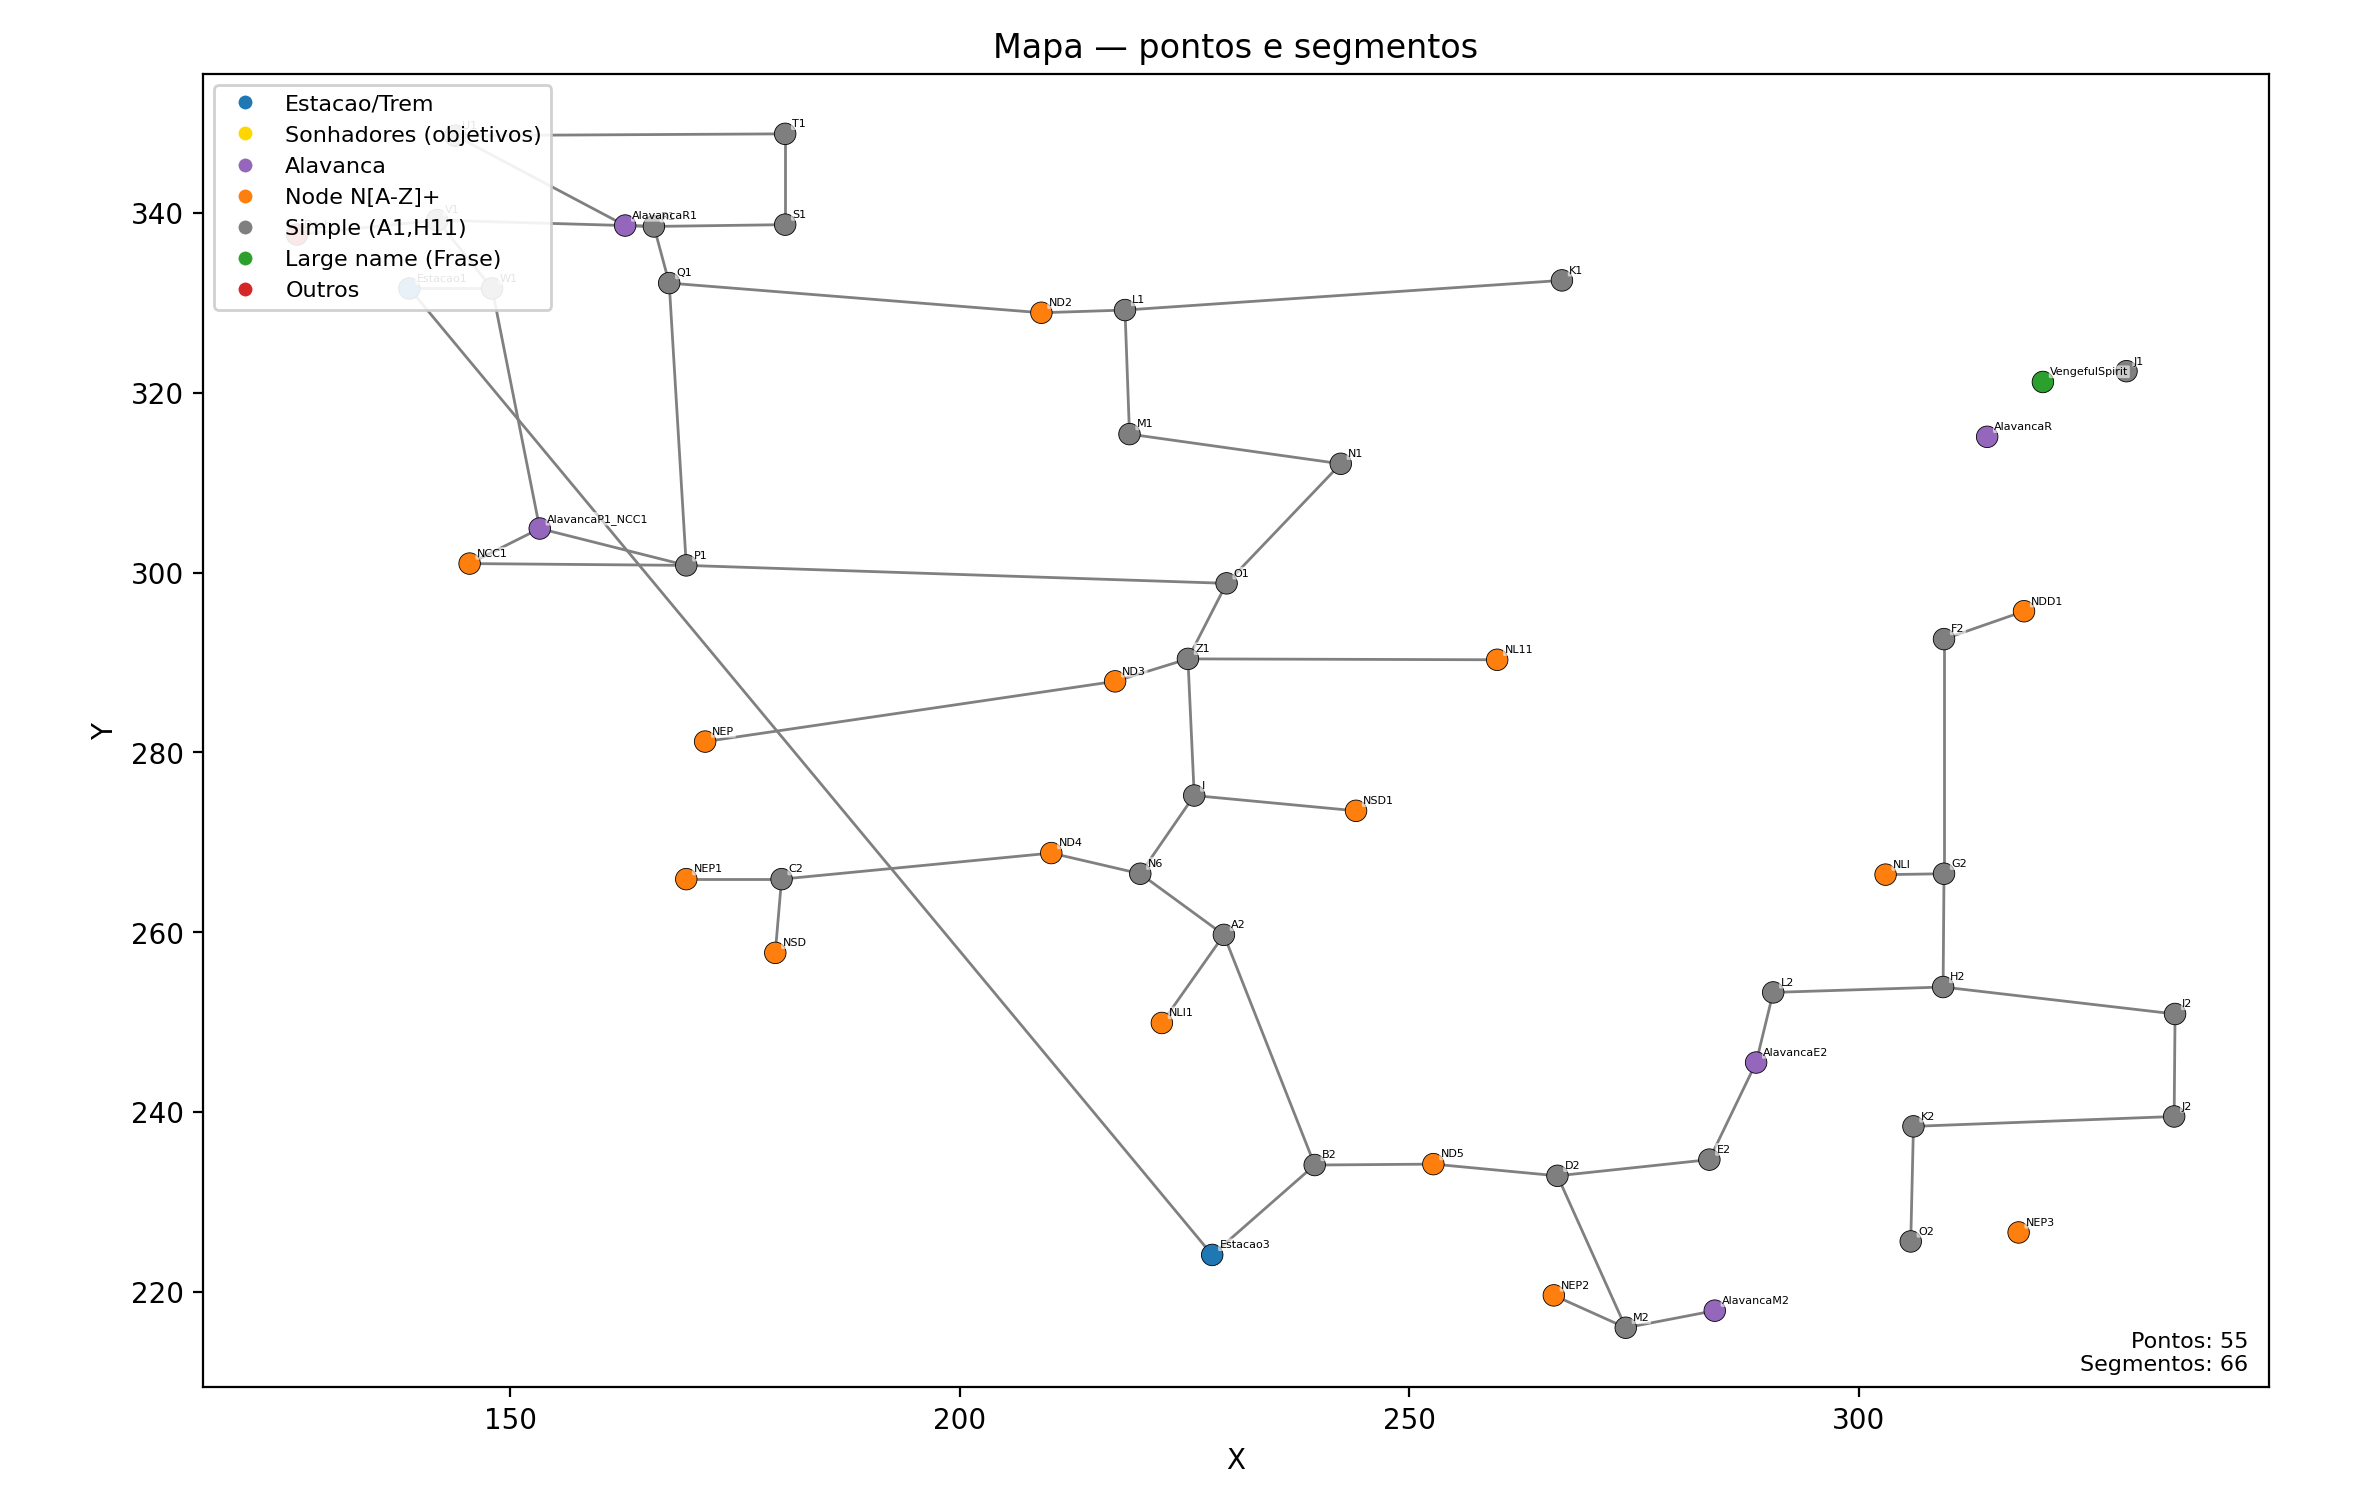

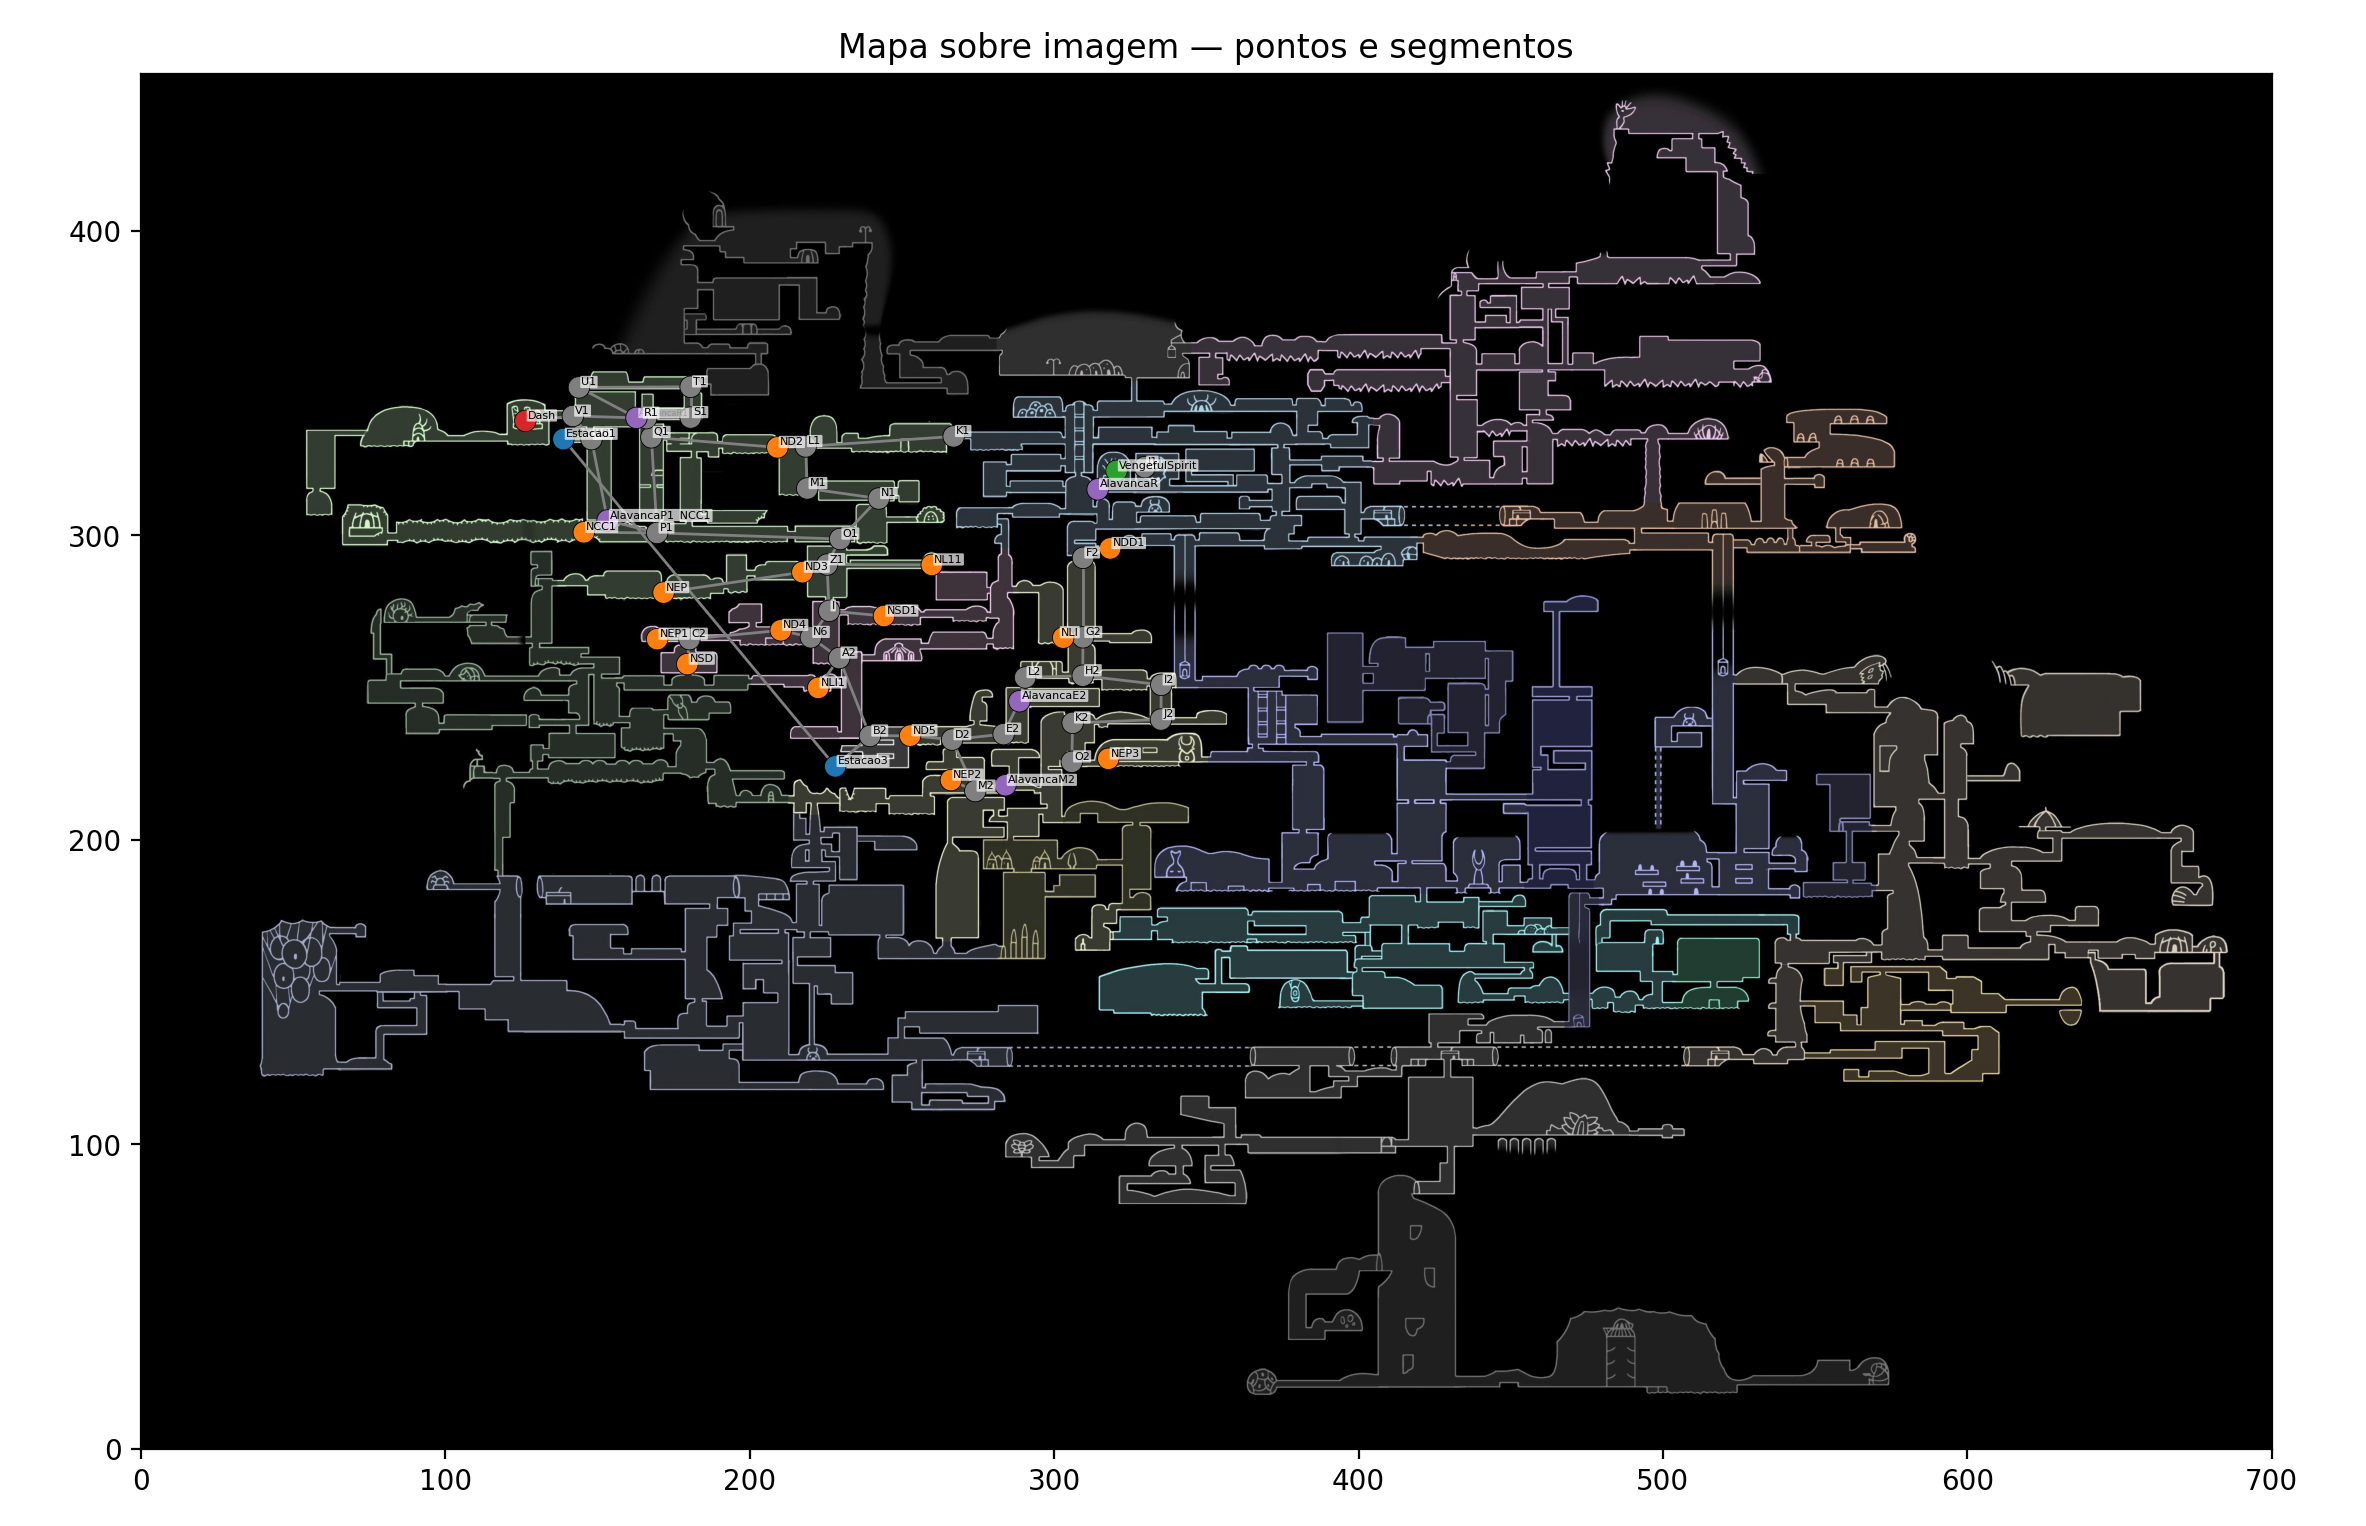

In [37]:
# Visualização do grafo com Matplotlib

BASE = Path.cwd()  # diretório atual do notebook
PONTOS_CSV = BASE / "data" / "pontos.csv"
SEGMENTOS_CSV = BASE / "data" / "segmentos.csv"
OUT_PNG = BASE / "images" / "mapa_plot.png"

if not PONTOS_CSV.exists() or not SEGMENTOS_CSV.exists():
    print('Arquivos `pontos.csv` ou `segmentos.csv` não encontrados no diretório:', BASE / "data")
    raise SystemExit(1)

# lê pontos
points = {}
with PONTOS_CSV.open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        name = row.get('name','').strip()
        x = row.get('x','').strip()
        y = row.get('y','').strip()
        try:
            xf = float(x)
            yf = float(y)
            points[name] = (xf, yf)
        except Exception:
            # ignora pontos sem coords válidas
            continue

# lê segmentos
segments = []
missing_points = set()
with SEGMENTOS_CSV.open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        name = row.get('name','').strip()
        start = row.get('start','').strip()
        end = row.get('end','').strip()
        length = row.get('length','').strip()
        # store
        segments.append({'name': name, 'start': start, 'end': end, 'length': length})
        if start not in points:
            missing_points.add(start)
        if end not in points:
            missing_points.add(end)

# Prepara plot
xs = [c[0] for c in points.values()]
ys = [c[1] for c in points.values()]

if xs and ys:
    minx, maxx = min(xs), max(xs)
    miny, maxy = min(ys), max(ys)
else:
    minx = miny = 0
    maxx = maxy = 1

# margin
dx = maxx - minx if maxx > minx else 1.0
dy = maxy - miny if maxy > miny else 1.0
margin = 0.05
padx = dx * margin
pady = dy * margin

fig_w = 10
# adapt figure size to aspect and to number of points (wider when many points)
num_points = max(1, len(points))
density_scale = min(3.0, 1.0 + (num_points / 300.0))
fig_h = max(6, (dy/dx) * fig_w) if dx > 0 else fig_w
fig = plt.figure(figsize=(fig_w * density_scale, fig_h * density_scale))
ax = fig.add_subplot(1,1,1)

# Draw segments first (so points/labels are on top)
for seg in segments:
    s = seg['start']
    e = seg['end']
    if s in points and e in points:
        x1,y1 = points[s]
        x2,y2 = points[e]
        ax.plot([x1,x2],[y1,y2], color='gray', linewidth=1, zorder=1)
    else:
        # skip drawing if missing
        continue

# Draw points
px = []
py = []
plabels = []
pcolors = []
def point_color(name: str) -> str:
    n = (name or '').strip()
    nl = n.lower()
    # Stations / trains -> blue (explicit)
    if 'estacao' in nl or 'trem' in nl or 'passe' in nl:
        return 'tab:blue'
    # Sonhadores (objetivos) -> gold (very special)
    if re.search(r'(?i)sonh', n):
        return 'gold'
    # Alavancas (contains 'Alavanca') -> purple
    if re.search(r'(?i)alavanc', n):
        return 'tab:purple'
    # Nodes that require a power: start with literal N followed by letters (e.g. NLL, NL, NVR)
    if re.match(r'^N[A-Z]+[0-9]*$', n):
        return 'tab:orange'
    # Simple nodes: only letters or letters followed by digits (A1, H11, K8)
    if re.match(r'^[A-Za-z]([0-9]+)?$', n):
        return 'tab:gray'
    # Big named things (single word, mostly letters, length >=5) -> highlight
    if len(n) >= 5 and re.match(r'^[A-Za-z]+$', n):
        return 'tab:green'
    # fallback: other special names
    return 'tab:red'
for name,(x,y) in points.items():
    px.append(x)
    py.append(y)
    plabels.append(name)
    pcolors.append(point_color(name))
# Compute a sensible marker size based on map scale and point density
try:
    # estimate closest neighbor distance (O(n^2) but n is moderate here)
    min_dist = None
    coords = list(points.values())
    n = len(coords)
    for i in range(n):
        x1,y1 = coords[i]
        for j in range(i+1, n):
            x2,y2 = coords[j]
            d = math.hypot(x2-x1, y2-y1)
            if d == 0:
                continue
            if min_dist is None or d < min_dist:
                min_dist = d
    if not min_dist or min_dist <= 0:
        min_dist = max(dx, dy) * 0.005
except Exception:
    min_dist = max(dx, dy) * 0.005

# marker size in points^2 (approx); inversely proportional to density
marker_size = max(6, min(60, (min(dx,dy) / (min_dist + 1e-9)) * 3))
ax.scatter(px, py, c=pcolors, s=marker_size, edgecolor='k', linewidth=0.3, zorder=2)

# Annotate all labels but scale font size and offset according to local density
x_range = maxx - minx if maxx>minx else 1.0
y_range = maxy - miny if maxy>miny else 1.0

# base offset: fraction of min distance between points
base_off = min_dist * 0.25
# ensure a minimum offset in data units
min_off = max(x_range, y_range) * 0.002
off = max(base_off, min_off)

# font sizing: smaller fonts when many points close together
font_size = max(4, min(10, int(8 * (min_dist / (max(dx, dy) * 0.05) + 0.2))))

# Place labels with a simple collision-avoidance heuristic:
# try a series of offsets and pick the first that doesn't collide with
# previously placed labels (measured by distance in data coordinates).
placed_labels = []  # list of (lx,ly) label anchor positions
label_sep = max(min_dist * 0.6, max(x_range, y_range) * 0.01)
offset_options = [
    (off, off), (off, -off), (-off, off), (-off, -off),
    (2*off, 0), (0, 2*off), (-2*off, 0), (0, -2*off)
]

for name, (x, y) in points.items():
    placed = False
    for dx_off, dy_off in offset_options:
        lx = x + dx_off
        ly = y + dy_off
        collision = False
        for px_l, py_l in placed_labels:
            if math.hypot(lx - px_l, ly - py_l) < label_sep:
                collision = True
                break
        if not collision:
            ax.annotate(name, (lx, ly), fontsize=font_size,
                        bbox=dict(boxstyle='round,pad=0.12', facecolor='white', alpha=0.6, edgecolor='none'),
                        zorder=3)
            placed_labels.append((lx, ly))
            placed = True
            break
        if not placed:
            # as a last resort, place with very small font and lower opacity to avoid clutter
            ax.annotate(name, (x + off, y + off), fontsize=max(3, font_size - 2),
                        color='gray', alpha=0.6,
                        bbox=dict(boxstyle='round,pad=0.08', facecolor='white', alpha=0.6, edgecolor='none'),
                        zorder=2)

ax.set_xlim(minx - padx, maxx + padx)
ax.set_ylim(miny - pady, maxy + pady)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Mapa — pontos e segmentos')
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Legend with counts
ax.text(0.99, 0.01, f'Pontos: {len(points)}\nSegmentos: {len(segments)}',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8,
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# color legend for point types
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label='Estacao/Trem', markerfacecolor='tab:blue', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Sonhadores (objetivos)', markerfacecolor='gold', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Alavanca', markerfacecolor='tab:purple', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Node N[A-Z]+', markerfacecolor='tab:orange', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Simple (A1,H11)', markerfacecolor='tab:gray', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Large name (Frase)', markerfacecolor='tab:green', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Outros', markerfacecolor='tab:red', markersize=6),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.9)

# Save
fig.tight_layout()
fig.savefig(OUT_PNG, dpi=200)
print('Imagem salva em:', OUT_PNG)
print('Pontos lidos:', len(points))
print('Segmentos lidos:', len(segments))
if any(missing_points):
    # remove empty names
    missing = sorted([m for m in missing_points if m])
    print('Aviso: os seguintes nomes referenciados em segmentos não foram encontrados em pontos.csv:')
    for m in missing[:50]:
        print(' -', m)
    if len(missing) > 50:
        print(' ... e mais', len(missing)-50, 'itens')
else:
    print('Todos os pontos referenciados em segmentos foram encontrados.')

print('Pronto.')

# Second plot: overlay points on background image (image.png)
IMG_PATH = BASE / "images" / "mapa.png"
OUT_PNG_BG = BASE / "images" / "mapa_plot_bg.png"

if IMG_PATH.exists():
    try:
        img = mpimg.imread(str(IMG_PATH))
        # flip the image vertically so it displays right-side-up on the plot
        try:
            img = np.flipud(img)
        except Exception:
            # if flip fails (e.g., unexpected array shape), fall back to original
            pass
        ih, iw = img.shape[0], img.shape[1]
        # map image width to x in [0,700]; scale y accordingly
        scale = 700.0 / float(iw)
        img_height_scaled = ih * scale

        fig2_w = max(10, fig_w * density_scale)
        fig2_h = max(6, (img_height_scaled / 700.0) * fig2_w)
        fig2 = plt.figure(figsize=(fig2_w, fig2_h))
        ax2 = fig2.add_subplot(1,1,1)

        # show image with origin at lower so (0,0) is bottom-left
        ax2.imshow(img, extent=[0, 700, 0, img_height_scaled], origin='lower')

        # draw segments on top (plot using image coords: bottom-left = (0,0))
        for seg in segments:
            s = seg['start']
            e = seg['end']
            if s in points and e in points:
                x1,y1 = points[s]
                x2,y2 = points[e]
                ax2.plot([x1,x2],[y1,y2], color='gray', linewidth=1, zorder=2)

        # draw points
        # use point coordinates directly (image origin is set to lower so (0,0) is bottom-left)
        px2 = [c[0] for c in points.values()]
        py2 = [c[1] for c in points.values()]
        # adapt marker size for image plot
        marker_size2 = marker_size
        # build color list for image overlay in same order as points.values()
        pkeys = list(points.keys())
        colors2 = [point_color(k) for k in pkeys]
        ax2.scatter(px2, py2, c=colors2, s=marker_size2, edgecolor='k', linewidth=0.3, zorder=3)

        # place labels using same heuristic but constrained to image extent
        placed_labels = []
        label_sep = max(min_dist * 0.6, max(700.0, img_height_scaled) * 0.01)
        offset_options = [
            (off, off), (off, -off), (-off, off), (-off, -off),
            (2*off, 0), (0, 2*off), (-2*off, 0), (0, -2*off)
        ]
        for name, (x, y) in points.items():
            placed = False
            for dx_off, dy_off in offset_options:
                # compute candidate label position in image coords
                lx = x + dx_off
                ly = y + dy_off
                # ensure label anchor inside image bounds
                if lx < 0 or lx > 700 or ly < 0 or ly > img_height_scaled:
                    continue
                collision = False
                for px_l, py_l in placed_labels:
                    if math.hypot(lx - px_l, ly - py_l) < label_sep:
                        collision = True
                        break
                if not collision:
                    ax2.annotate(name, (lx, ly), fontsize=font_size,
                                     bbox=dict(boxstyle='round,pad=0.10', facecolor='white', alpha=0.7, edgecolor='none'),
                                     zorder=4)
                    placed_labels.append((lx, ly))
                    placed = True
                    break
            if not placed:
                ax2.annotate(name, (x + off, y + off), fontsize=max(3, font_size - 2),
                             color='gray', alpha=0.6,
                             bbox=dict(boxstyle='round,pad=0.08', facecolor='white', alpha=0.6, edgecolor='none'),
                             zorder=3)

        ax2.set_xlim(0, 700)
        ax2.set_ylim(0, img_height_scaled)
        ax2.set_aspect('equal', adjustable='box')
        ax2.set_title('Mapa sobre imagem — pontos e segmentos')

        fig2.tight_layout()
        fig2.savefig(OUT_PNG_BG, dpi=200)
        print('Imagem com fundo salva em:', OUT_PNG_BG)
        plt.close(fig2)
    except Exception as exc:
        print('Falha ao gerar imagem com fundo:', exc)
else:
    print('Arquivo de imagem `image.png` não encontrado em:', IMG_PATH)


display(Image(filename=str(Path.cwd() / "images" / "mapa_plot.png")))
display(Image(filename=str(Path.cwd() / "images" / "mapa_plot_bg.png")))
plt.close(fig)

## 3. Construção do grafo direcionado

Nesta seção, definimos os nós especiais de nosso problema, fazemos o mapeamento de poderes para vértices e armazenamos outros tipos de requisitos. Com essas informações, construímos o grafo direcionado $G$ a partir dos arquivos CSV e de outras informações do problema e exportamos os parâmetros de configuração do problema em um arquivo JSON.

Na célula de código abaixo, definimos:
- **Nós especiais**: vértice inicial, vértice final e nós obrigatórios da rota. Esses vértices podem mudar dependendo de nosso caso teste
- **Mapeamento de poderes**: associação entre prefixos de nomes de vértices (ex: `ND`, `NEP`) e os poderes necessários para acessá-los (ex: `MOTHWING_CLOAK`, `MANTIS_CLAW`)
- **Requisitos de visita**: vértices que exigem ter passado por outros vértices previamente (não relacionados a poderes)

In [38]:
# Definição dos nós especiais do problema

START_NODE = "K1"                 # nó inicial
EXIT_NODE = "Estacao1"            # nó final
REQUIRED_NODES = ["D2"] # nós obrigatórios


# Mapeamento de prefixos para poderes necessários (requisitos de poder)
prefix_to_power = {
    "ND": "MOTHWING_CLOAK",    # Node Dash
    "NEP": "MANTIS_CLAW",      # Node Mantis Claw (Escalada)
    "NCC": "CRYSTAL_HEART",    # Node Crystal Dash
    "NCH": "CRYSTAL_HEART",    # Node Crystal Heart
    "NLI": "ISMAS_TEAR",       # Node Lagrima Isma (nadar em ácido)
    "NAM": "MONARCH_WINGS",    # Node Asas Monarca (pulo duplo)
    "NSD": "SHADE_CLOAK",      # Node Shadow Dash (dash sombrio)
    "NL": "LUMAFLY_LANTERN",   # Node Lanterna
    "NPasse": "TRAM_PASS",     # Node Passe Bonde
    "NTrem": "TRAM_PASS",      # Node Passe Bonde
    "NVR": "VENGEFUL_SPIRIT",  # Node Vengeful Spirit
    "NDD": "DESOLATE_DIVE"     # Node Desolate Dive
}

# Mapeamento dos poderes para seus nomes de nó correspondentes
# Formato: {poder: nó_correspondente}
power_to_node = {
    "MANTIS_CLAW": "MantisClaw",
    "MOTHWING_CLOAK": "Dash",
    "CRYSTAL_HEART": "CrystalHeart",
    "ISMAS_TEAR": "LagrimaIsma",
    "MONARCH_WINGS": "AsasMonarca",
    "SHADE_CLOAK": "ShadeDash",
    "LUMAFLY_LANTERN": "Luz",
    "TRAM_PASS": "PASSEBONDE",
    "VENGEFUL_SPIRIT": "VengefulSpirit",
    "DESOLATE_DIVE": "DesolateDive",
    "DREAM_NAIL": "FERRAOSONHOS"
}

# Mapeamento hardcoded de requisitos de visita prévia (não-poder)
# Formato: {nó_destino: nó_que_deve_ser_visitado_antes}
# Para múltiplos requisitos AND, use uma lista
node_visit_requirements = {
    "NBOSS": "BOSS",                     # Para acessar NBOSS, precisa ter passado por BOSS
    "LUZ": ["Slyloja", "DinheiroLuz"],   # Para comprar a luz, precisa de Slyloja AND DinheiroLuz (AND)
    "BrasaoCidade": "J1",                # Para pegar o brasão da cidade, precisa ter passado por J1
}

Na célula de código abaixo, construímos o grafo direcionado $G$ a partir dos arquivos CSV e das informações de configuração do problema definidos acima: cada ponto vira um nó e cada segmento vira uma aresta seu valor de comprimento. Além disso, fazemos também uma classificação dos nós (estações, alavancas, nós com requisito de poder/visita ou regulares), marcação dos nós especiais (início, fim, obrigatórios) e associação de quais nós concedem poderes. Em seguida, criamos as arestas normalmente bidirecionais, tratando casos especiais de alavancas e da aresta BrasaoCidade → C8 (unidirecional e de uso único), e, por fim, imprimimos um resumo das quantidades e tipos de nós e arestas do grafo.


In [39]:
# 2. Construção do grafo direcionado com NetworkX
G = nx.DiGraph()


def parse_power_requirement(node_name):
    """
    Detecta requisitos de poder de um nó, incluindo OR.
    Retorna lista de listas: [[poder1], [poder2]] = OR, [[poder1, poder2]] = AND
    Retorna None se o nó não requer poderes.
    """
    # Verifica se o nome começa com N seguido de letra maiúscula
    if not node_name.startswith("N"):
        return None
    if len(node_name) < 2:
        return None
    # Verifica se o segundo caractere é uma letra maiúscula
    if not node_name[1].isupper():
        return None
    
    or_match = re.search(r'^N([A-Z]+)or([A-Z]+)', node_name)
    if or_match:
        prefix1 = or_match.group(1)
        prefix2 = or_match.group(2)
        
        powers_or = []
        for prefix in [prefix1, prefix2]:
            found = False
            for key, power in prefix_to_power.items():
                if key.startswith("N" + prefix):
                    powers_or.append([power])
                    found = True
                    break
            if not found:
                full_key = "N" + prefix
                if full_key in prefix_to_power:
                    powers_or.append([prefix_to_power[full_key]])
        
        if len(powers_or) == 2:
            return powers_or
    
    for prefix, power in prefix_to_power.items():
        if node_name.startswith(prefix):
            return [[power]]
    
    return None


def get_lever_targets(name):
    """Retorna os vértices alvos que uma alavanca desbloqueia."""
    if not name.startswith("Alavanca") or name == "Alavanca0":
        return []
    
    suffix = name[8:]
    
    if suffix == "U61":
        return ["AlavancaU6"]
        
    if "_" in suffix:
        return suffix.split("_")
    
    return [suffix]


# Adicionar nós ao grafo
node_col = "name" if "name" in pontos_df.columns else pontos_df.columns[0]

for _, row in pontos_df.iterrows():
    node = row[node_col]
    attrs = row.to_dict()
    
    if 'x' in attrs:
        attrs['x'] = float(attrs['x'])
    if 'y' in attrs:
        attrs['y'] = float(attrs['y'])
    
    if node.startswith("Estacao"):
        attrs['node_type'] = 'estacao'
        attrs['is_station'] = True
        attrs['is_lever'] = False
        attrs['is_power_node'] = False
        attrs['required_power'] = None
        attrs['requires_visit'] = node_visit_requirements.get(node, None)
        
    elif node.startswith("Alavanca"):
        attrs['node_type'] = 'alavanca'
        attrs['is_station'] = False
        attrs['is_lever'] = True
        attrs['is_power_node'] = False
        attrs['required_power'] = None
        attrs['requires_visit'] = node_visit_requirements.get(node, None)
        
    elif node.startswith("N") and len(node) > 1 and node[1].isupper():
        # Vértices do tipo NXX (N seguido de letras maiúsculas) - requerem poderes
        attrs['node_type'] = 'node_n'
        attrs['is_station'] = False
        attrs['is_lever'] = False
        attrs['is_power_node'] = False
        attrs['required_power'] = parse_power_requirement(node)
        attrs['requires_visit'] = node_visit_requirements.get(node, None)
        
    else:
        attrs['node_type'] = 'regular'
        attrs['is_station'] = False
        attrs['is_lever'] = False
        attrs['is_power_node'] = False
        attrs['required_power'] = None
        attrs['requires_visit'] = node_visit_requirements.get(node, None)
    
    # 2. Marcar nós que concedem poderes
    attrs['gives_power'] = None
    for power_name, power_node in power_to_node.items():
        # Exemplo: se node == "MantisClaw", e temos "MANTIS_CLAW": "MantisClaw" no power_to_node
        # Precisamos verificar no dicionário invertido
        pass
    
    # 3. Marcar nós obrigatórios (Sonhadores)
    attrs['is_required'] = node in REQUIRED_NODES  # Usa a configuração definida no início
    
    # 4. Marcar START e FINALBOSS
    attrs['is_start'] = (node == START_NODE)  # Usa a configuração definida no início
    attrs['is_exit'] = (node == EXIT_NODE)    # Usa a configuração definida no início
        
    G.add_node(node, **attrs)

for power, node_name in power_to_node.items():
    if node_name in G.nodes:
        G.nodes[node_name]['gives_power'] = power

# segmentos.csv tem colunas 'start', 'end' e 'length'
start_col = "start"
end_col = "end"
length_col = "length"

for _, row in segmentos_df.iterrows():
    i = row[start_col]
    j = row[end_col]
    length = float(row[length_col])
    
    targets_i = get_lever_targets(i)
    targets_j = get_lever_targets(j)
    
    # Por padrão, assume que o caminho é bidirecional (ida e volta)
    add_i_to_j = True
    add_j_to_i = True
    
    # REGRA: Se i é Alavanca e j é um dos seus alvos, então i -> j é permitido (caiu/abriu), mas j -> i é PROIBIDO (não volta)
    if j in targets_i:
        add_j_to_i = False
        
    # REGRA: Se j é Alavanca e i é um dos seus alvos, então j -> i é permitido, mas i -> j é PROIBIDO
    if i in targets_j:
        add_i_to_j = False
    
    # REGRA ESPECIAL: BrasaoCidade -> C8 é unidirecional e só pode ser usada uma vez
    if i == "BrasaoCidade" and j == "C8":
        add_j_to_i = False

    base_attrs = row.to_dict()
    base_attrs['length'] = length
    
    if add_i_to_j:
        edge_attrs = base_attrs.copy()
        # Marcar se esta aresta foi desbloqueada por uma alavanca
        edge_attrs['unlocked_by_lever'] = None  # Será None ou o nome da alavanca
        edge_attrs['requires_power'] = set()    # Poderes necessários para usar a aresta
        edge_attrs['single_use'] = False        # Aresta pode ser usada múltiplas vezes (padrão)
        
        # BrasaoCidade -> C8 é uma aresta de uso único
        if i == "BrasaoCidade" and j == "C8":
            edge_attrs['single_use'] = True
        
        if j in targets_i:
            edge_attrs['unlocked_by_lever'] = i
            
        G.add_edge(i, j, **edge_attrs)
        
    if add_j_to_i:
        edge_attrs = base_attrs.copy()
        edge_attrs['unlocked_by_lever'] = None
        edge_attrs['requires_power'] = set()
        edge_attrs['single_use'] = False
        
        if i in targets_j:
            edge_attrs['unlocked_by_lever'] = j
            
        G.add_edge(j, i, **edge_attrs)


# Alavanca aponta para o vértice que consegue acessar, mas o vértice não consegue acessar a alavanca
# OBS: Alavanca U6' e AlavancaAlavancaA6 (essa nunca tem o booleano), Alavanca0

print("=== GRAFO CONSTRUÍDO COM SUCESSO ===")
print(f"Nós: {len(G.nodes)}")
print(f"Arestas: {len(G.edges)}")

print("\n=== CONFIGURAÇÕES ATIVAS DO PROBLEMA ===")
print(f"Vértice inicial: {START_NODE}")
print(f"Vértice final: {EXIT_NODE}")
print(f"Nós obrigatórios: {REQUIRED_NODES} ({len(REQUIRED_NODES)} nós)")


print("\n=== Resumo da Classificação dos Nós ===")
print(f"Estações: {sum(1 for n, d in G.nodes(data=True) if d.get('is_station'))}")
print(f"Alavancas: {sum(1 for n, d in G.nodes(data=True) if d.get('is_lever'))}")

# Contar vértices com requisitos de poder (required_power não é None)
nodes_with_power_req = [n for n, d in G.nodes(data=True) if d.get('required_power') is not None]
print(f"Vértices com requisito de poder: {len(nodes_with_power_req)}")

# Contar vértices com requisitos de visita (requires_visit não é None)
nodes_with_visit_req = [n for n, d in G.nodes(data=True) if d.get('requires_visit') is not None]
print(f"Vértices com requisito de visita prévia: {len(nodes_with_visit_req)}")

print(f"Nós regulares (sem requisitos): {sum(1 for n, d in G.nodes(data=True) if d.get('node_type') == 'regular')}")

lever_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('unlocked_by_lever')]
print(f"\nArestas desbloqueadas por alavancas: {len(lever_edges)}")

single_use_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('single_use')]
print(f"Arestas de uso único: {len(single_use_edges)}")
if single_use_edges:
    for u, v in single_use_edges:
        print(f"  - {u} -> {v}")

# # Listar vértices com requisitos
# if nodes_with_power_req:
#     print(f"\n=== Vértices com Requisitos de Poder ({len(nodes_with_power_req)}) ===")
#     for node in sorted(nodes_with_power_req):
#         req = G.nodes[node]['required_power']
#         print(f"  {node}: {req}")

if nodes_with_visit_req:
    print(f"\n=== Vértices com Requisitos de Visita ({len(nodes_with_visit_req)}) ===")
    for node in sorted(nodes_with_visit_req):
        req = G.nodes[node]['requires_visit']
        print(f"  {node} requer visitar: {req}")


=== GRAFO CONSTRUÍDO COM SUCESSO ===
Nós: 62
Arestas: 124

=== CONFIGURAÇÕES ATIVAS DO PROBLEMA ===
Vértice inicial: K1
Vértice final: Estacao1
Nós obrigatórios: ['D2'] (1 nós)

=== Resumo da Classificação dos Nós ===
Estações: 2
Alavancas: 5
Vértices com requisito de poder: 15
Vértices com requisito de visita prévia: 0
Nós regulares (sem requisitos): 33

Arestas desbloqueadas por alavancas: 6
Arestas de uso único: 0


Imagem salva em: c:\Users\guilh\OneDrive\Faculdade\FACULDADE\6° período\OTM\Trab\images\grafo_direcionado.png


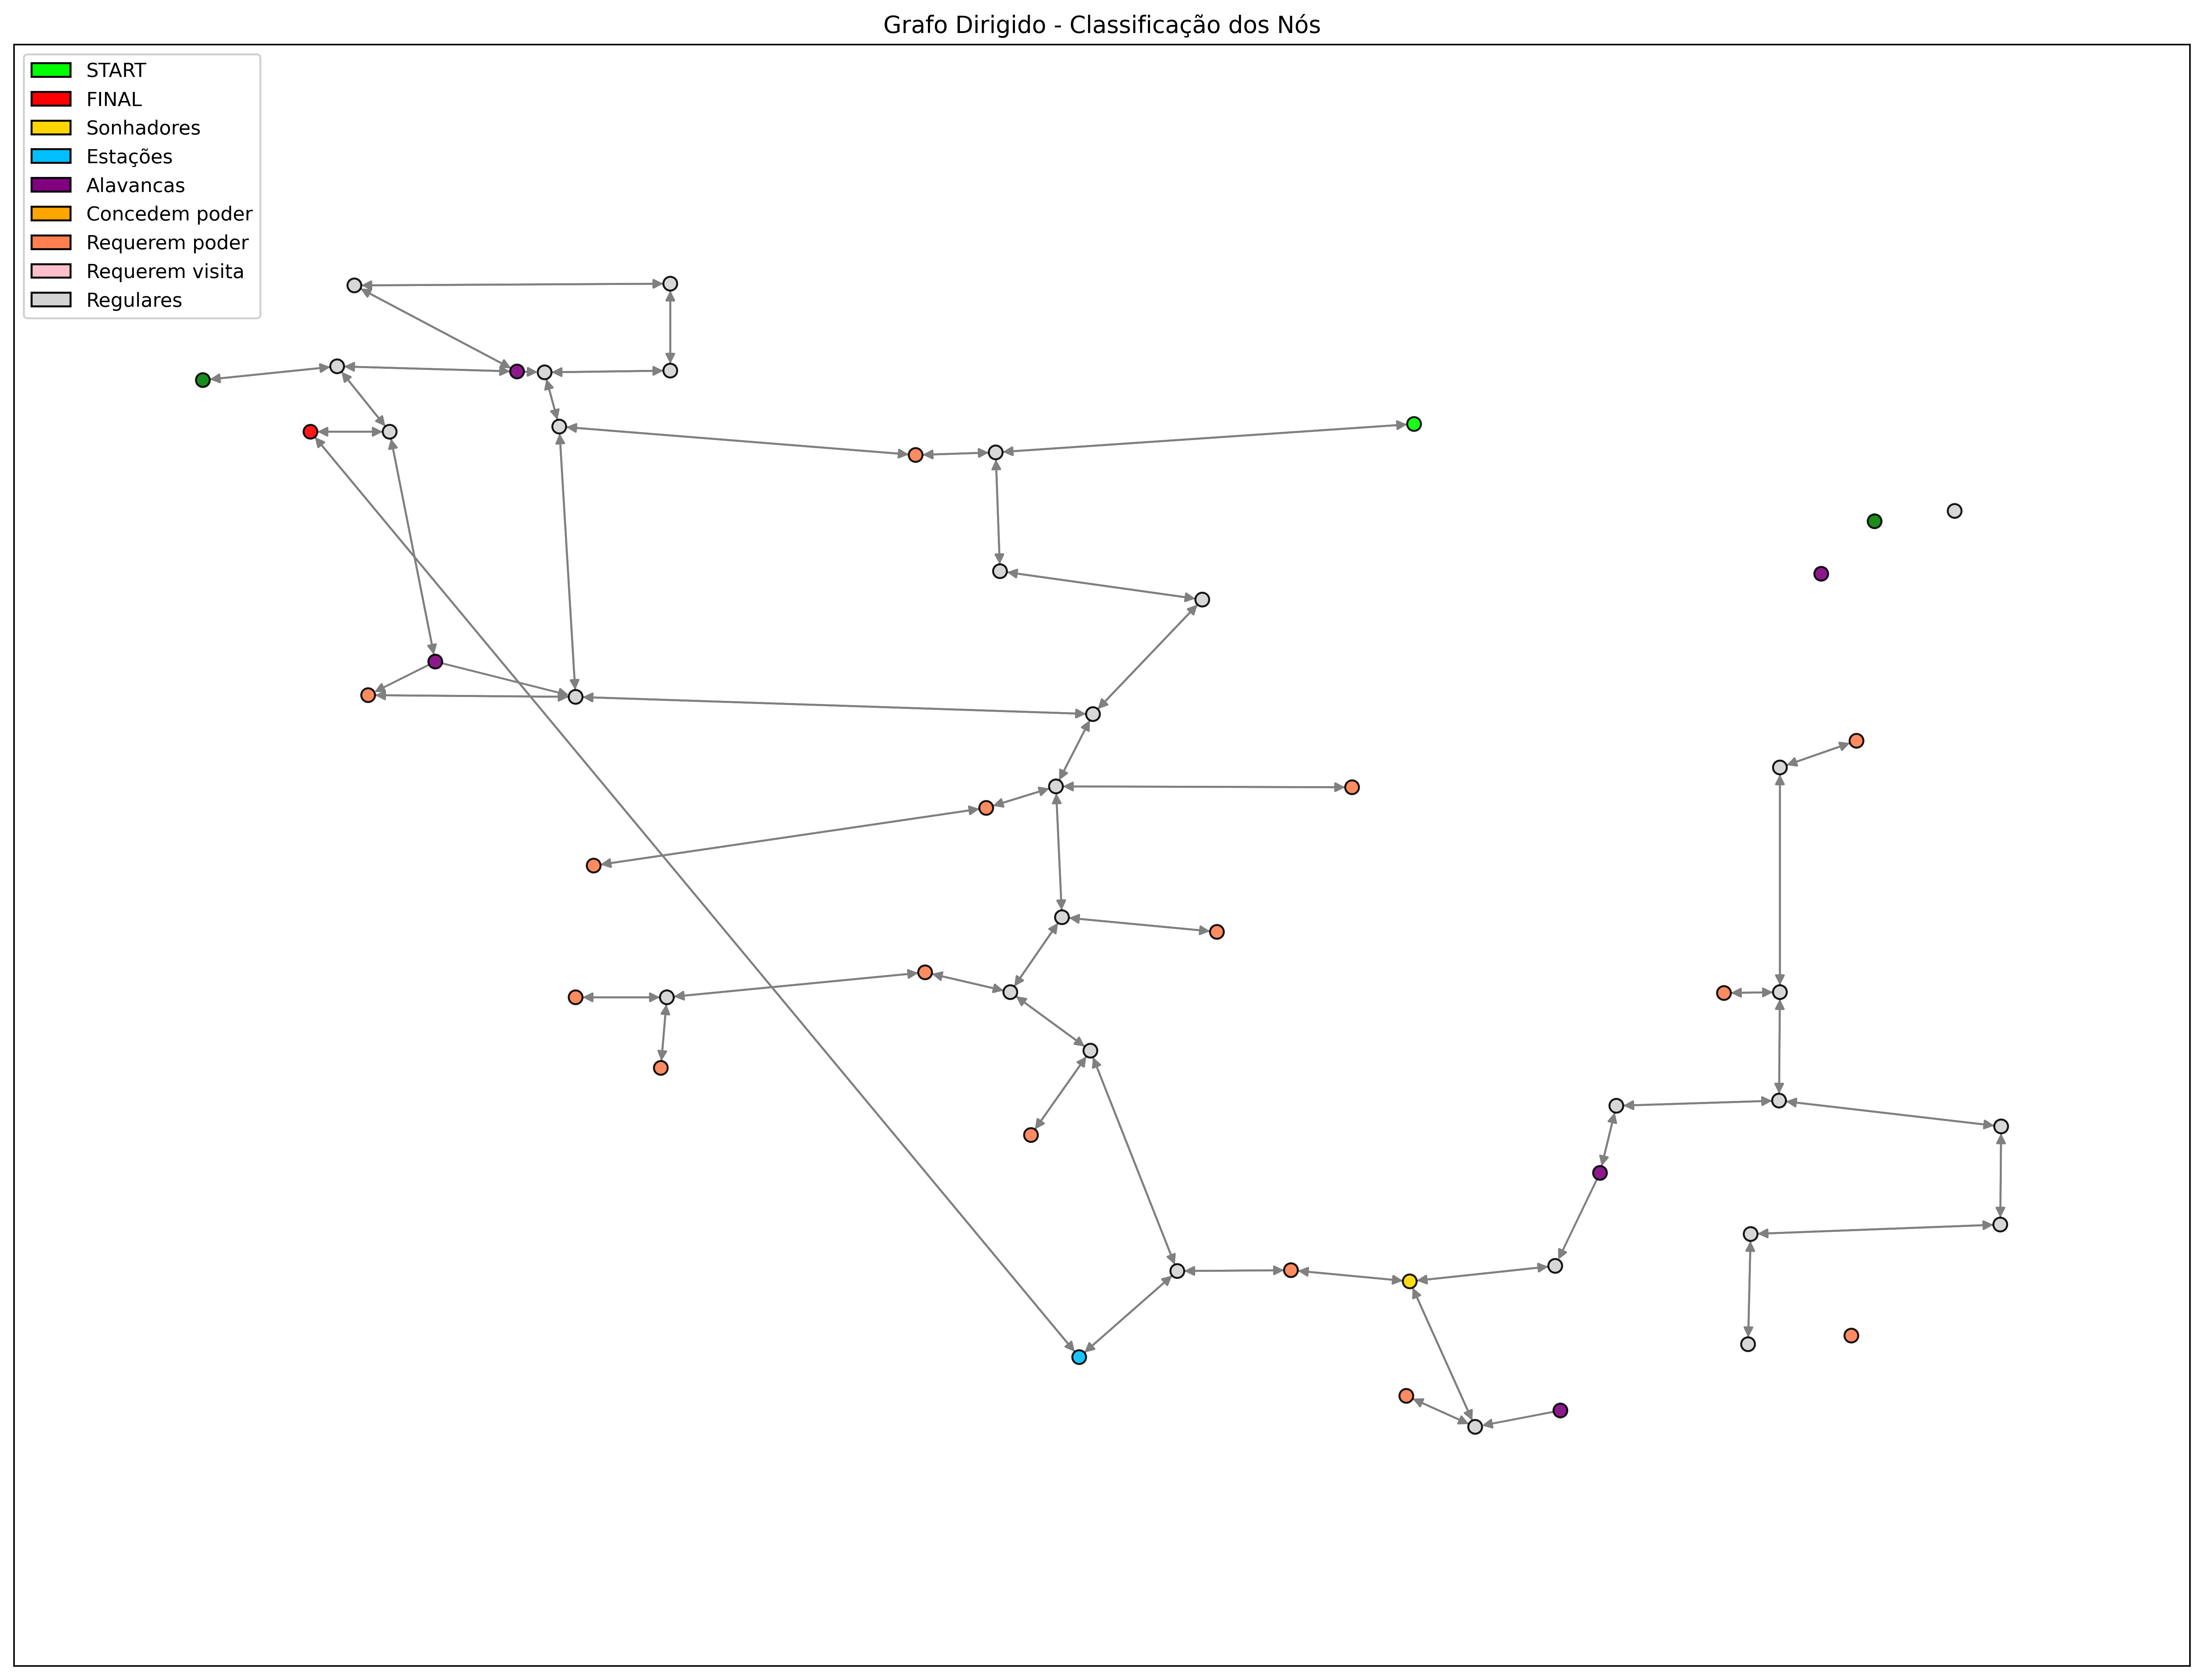

In [40]:
# --- Visualização do Grafo G ---
plt.figure(figsize=(20, 15))

# 1. Extrair posições (x, y) de forma robusta — alguns nós podem não ter 'x'/'y'
pos = {}
for n, data in G.nodes(data=True):
    x = data.get('x')
    y = data.get('y')
    if x is None or y is None:
        # pula nós sem coordenadas (evita KeyError)
        continue
    pos[n] = (x, y)

# 2. Definir lista de nós a desenhar e cores baseadas na classificação
nodelist = list(pos.keys())
node_colors = []
for n in nodelist:
    node_data = G.nodes[n]
    
    # Prioridade: nós especiais primeiro
    if node_data.get('is_start'):
        node_colors.append('lime')  # START - verde claro
    elif node_data.get('is_exit'):
        node_colors.append('red')  # FINALBOSS - vermelho
    elif node_data.get('is_required'):
        node_colors.append('gold')  # Sonhadores - dourado
    
    # Classificação por tipo de nó
    elif node_data.get('is_station'):
        node_colors.append('deepskyblue')  # Estações - azul céu
    elif node_data.get('is_lever'):
        node_colors.append('purple')  # Alavancas - roxo
    elif node_data.get('gives_power') is not None:
        node_colors.append('green')  # Nós que concedem poderes - olive
    elif node_data.get('required_power') is not None:
        node_colors.append('coral')  # Nós que requerem poderes - coral
    elif node_data.get('requires_visit') is not None:
        node_colors.append('pink')  # Nós que requerem visitas - rosa
    else:
        node_colors.append('lightgray')  # Nós regulares - cinza claro

# Tamanho dos nós (usado para desenhar o nó e calcular onde a seta para)
node_size_val = 50

# 3. Desenhar nós
nx.draw_networkx_nodes(G, pos, nodelist=nodelist, node_size=node_size_val, node_color=node_colors, alpha=0.9, edgecolors='black')

# 4. Desenhar arestas
edgelist = [(u, v) for u, v in G.edges() if u in pos and v in pos]

nx.draw_networkx_edges(
    G, pos, 
    edgelist=edgelist, 
    edge_color='gray',
    arrows=True, 
    arrowstyle='-|>', 
    arrowsize=10, 
    width=1.0,
    node_size=node_size_val,  # CRUCIAL: Informa o tamanho do nó para a seta encostar corretamente
)

# Adicionar legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lime', edgecolor='black', label='START'),
    Patch(facecolor='red', edgecolor='black', label='FINAL'),
    Patch(facecolor='gold', edgecolor='black', label='Sonhadores'),
    Patch(facecolor='deepskyblue', edgecolor='black', label='Estações'),
    Patch(facecolor='purple', edgecolor='black', label='Alavancas'),
    Patch(facecolor='orange', edgecolor='black', label='Concedem poder'),
    Patch(facecolor='coral', edgecolor='black', label='Requerem poder'),
    Patch(facecolor='pink', edgecolor='black', label='Requerem visita'),
    Patch(facecolor='lightgray', edgecolor='black', label='Regulares'),
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

# Opcional: Labels pequenos para ajudar na identificação (descomente se quiser)
# nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

plt.title("Grafo Dirigido - Classificação dos Nós")
plt.axis('equal')

# 5. Salvar a imagem e exibir
output_filename = "grafo_direcionado.png"
output_path = BASE / "images" / output_filename
plt.savefig(output_path, dpi=400, bbox_inches='tight')
plt.close()

print(f"Imagem salva em: {output_path}")
display(Image(filename=str(output_path)))

Já o código abaixo identifica todos os nós e estados especiais no grafo já construído e prepara os conjuntos necessários para a expansão de estados e para o modelo de otimização. Em resumo, ela:

- Lê os atributos dos nós de G para separar: nós de início/fim, estações, alavancas, sonhadores (nós obrigatórios), nós que concedem poderes e nós com requisitos de poder/visita.
- Monta dicionários auxiliares (stations_dict, levers_dict, powers_dict, requires_dict) que indicam quem desbloqueia o quê e quais poderes/visitas são necessários em cada vértice/aresta.
- Calcula o conjunto de sonhadores necessários e imprime um resumo desses conjuntos, além de criar um arquivo JSON com esses conjuntos, servindo como preparação para a etapa seguinte de expansão de estados e formulação do MILP.

In [41]:
import json
from pathlib import Path

BASE = Path.cwd()

print("=== Gerando Configuração JSON a partir do Grafo ===\n")

# 1. Identificar nó inicial e final
origin = None
destination = None
for node, data in G.nodes(data=True):
    if data.get('is_start'):
        origin = node
    if data.get('is_exit'):
        destination = node

if not origin or not destination:
    raise ValueError("Nós inicial e/ou final não foram encontrados no grafo!")

print(f"- Nó inicial: {origin}")
print(f"- Nó final: {destination}")

# 2. Coletar nós obrigatórios
sonhadores_list = [node for node, data in G.nodes(data=True) if data.get('is_required')]
print(f"- Nós obrigatórios ({len(sonhadores_list)}): {sonhadores_list}")

# 3. Coletar Estações
stations_list = [node for node, data in G.nodes(data=True) if data.get('is_station')]
print(f"- Estações ({len(stations_list)}): {', '.join(stations_list[:5])}{'...' if len(stations_list) > 5 else ''}")

# 4. Coletar Alavancas e seus alvos (usando a função já definida)
levers_dict = {}
for node in G.nodes():
    if G.nodes[node].get('is_lever'):
        targets = get_lever_targets(node)
        if targets:
            levers_dict[node] = targets

print(f"- Alavancas ({len(levers_dict)})")

# 5. Criar mapeamento de poderes (poder -> nó que concede)
# Usar o dicionário power_to_node já definido na construção do grafo

powers_dict = power_to_node.copy()
print(f"- Poderes disponíveis ({len(powers_dict)}):")
for power, node in powers_dict.items():
    print(f"    {power} -> {node}")

# 6. Coletar requisitos COMPLETOS do problema
# Precisamos mapear tanto requisitos de VÉRTICES quanto de ARESTAS

requires_dict = {}

# 6.1. Requisitos de VÉRTICES (poderes necessários para acessar um nó)
for node, data in G.nodes(data=True):
    req_power = data.get('required_power')
    req_visit = data.get('requires_visit')
    
    # Processar requisitos de poder
    if req_power is not None:
        # req_power é lista de listas: [[p1], [p2]] = OR, [[p1, p2]] = AND
        # Converter para formato de string que o algoritmo de expansão entenda
        if len(req_power) == 1 and len(req_power[0]) == 1:
            # Caso simples: único poder (AND com 1 elemento)
            requires_dict[node] = req_power[0]  # ["CRYSTAL_HEART"]
        elif len(req_power) == 2 and all(len(p) == 1 for p in req_power):
            # Caso OR: dois poderes alternativos
            # Precisamos marcar como OR no dicionário, usamos estrutura especial {"or": [[p1], [p2]]}
            # Mas para compatibilidade, vamos usar lista plana e tratar no has_required
            requires_dict[node] = [p[0] for p in req_power]  # Lista plana para OR
        else:
            # Caso AND: múltiplos poderes necessários
            # Flatten para lista simples
            flat_list = [p for sublist in req_power for p in sublist]
            requires_dict[node] = flat_list
    
    # Processar requisitos de visita prévia
    # Nota: requires_visit não é sobre poderes, é sobre ter visitado outros nós
    # Isso será tratado separadamente na função has_required

# 6.2. Requisitos de ARESTAS (poderes necessários para usar uma aresta)
for u, v, data in G.edges(data=True):
    req_powers = data.get('requires_power', set())
    if req_powers:
        edge_key = f"({u},{v})"
        requires_dict[edge_key] = sorted(list(req_powers))

print(f"- Requisitos mapeados:")
print(f"    Vértices com requisitos de poder: {sum(1 for k in requires_dict if not k.startswith('('))}")
print(f"    Arestas com requisitos de poder: {sum(1 for k in requires_dict if k.startswith('('))}")

# 7. Coletar requisitos de visita prévia (separadamente)
visit_requirements = {}
for node, data in G.nodes(data=True):
    req_visit = data.get('requires_visit')
    if req_visit is not None:
        visit_requirements[node] = req_visit

print(f"- Requisitos de visita prévia ({len(visit_requirements)}):")
for node, req in visit_requirements.items():
    if isinstance(req, list):
        print(f"    {node} requer visitar: {' AND '.join(req)}")
    else:
        print(f"    {node} requer visitar: {req}")

# 8. Coletar arestas de uso único
single_use_edges = []
for u, v, data in G.edges(data=True):
    if data.get('single_use', False):
        single_use_edges.append([u, v])

if single_use_edges:
    print(f"- Arestas de uso único ({len(single_use_edges)}):")
    for u, v in single_use_edges:
        print(f"    {u} -> {v}")

# 9. Montar configuração completa
config_template = {
    "start": origin,
    "exit": destination,
    "sonhadores": sonhadores_list,
    "powers": powers_dict,
    "requires": requires_dict,
    "visit_requirements": visit_requirements,
    "levers": levers_dict,
    "stations": stations_list,
    "single_use_edges": single_use_edges,
    "teleport_cost": 0.1,
    "metadata": {
        "description": "Configuração gerada automaticamente do grafo NetworkX",
        "total_nodes": len(G.nodes()),
        "total_edges": len(G.edges()),
        "generation_timestamp": "auto-generated"
    }
}

CONFIG_PATH = BASE / "hollow_config.json"

# Sempre sobrescrever com a configuração mais recente do grafo
with CONFIG_PATH.open("w", encoding="utf-8") as fh:
    json.dump(config_template, fh, indent=2, ensure_ascii=False)

print(f"\n- Configuração salva em: {CONFIG_PATH}")
config = config_template

print("\n" + "="*60)
print("RESUMO DA CONFIGURAÇÃO")
print("="*60)
print(f"Nó inicial: {config['start']}")
print(f"Nó final: {config['exit']}")
print(f"Sonhadores obrigatórios: {len(config['sonhadores'])}")
print(f"Estações de teleporte: {len(config['stations'])}")
print(f"Alavancas: {len(config['levers'])}")
print(f"Poderes disponíveis: {len(config['powers'])}")
print(f"Nós com requisitos: {sum(1 for k in config['requires'] if not k.startswith('('))}")
print(f"Arestas com requisitos: {sum(1 for k in config['requires'] if k.startswith('('))}")
print(f"Nós com requisitos de visita: {len(config['visit_requirements'])}")
print(f"Arestas de uso único: {len(config['single_use_edges'])}")
print(f"Custo de teleporte: {config['teleport_cost']}")
print("="*60)

=== Gerando Configuração JSON a partir do Grafo ===

- Nó inicial: K1
- Nó final: Estacao1
- Nós obrigatórios (1): ['D2']
- Estações (2): Estacao1, Estacao3
- Alavancas (5)
- Poderes disponíveis (11):
    MANTIS_CLAW -> MantisClaw
    MOTHWING_CLOAK -> Dash
    CRYSTAL_HEART -> CrystalHeart
    ISMAS_TEAR -> LagrimaIsma
    MONARCH_WINGS -> AsasMonarca
    SHADE_CLOAK -> ShadeDash
    LUMAFLY_LANTERN -> Luz
    TRAM_PASS -> PASSEBONDE
    VENGEFUL_SPIRIT -> VengefulSpirit
    DESOLATE_DIVE -> DesolateDive
    DREAM_NAIL -> FERRAOSONHOS
- Requisitos mapeados:
    Vértices com requisitos de poder: 15
    Arestas com requisitos de poder: 0
- Requisitos de visita prévia (0):

- Configuração salva em: c:\Users\guilh\OneDrive\Faculdade\FACULDADE\6° período\OTM\Trab\hollow_config.json

RESUMO DA CONFIGURAÇÃO
Nó inicial: K1
Nó final: Estacao1
Sonhadores obrigatórios: 1
Estações de teleporte: 2
Alavancas: 5
Poderes disponíveis: 11
Nós com requisitos: 15
Arestas com requisitos: 0
Nós com requisi

## 4. Modelo Matemático

O problema consiste em encontrar a menor rota possível no grafo de Hollow Knight, permitindo revisitar vértices, mas exigindo:

- Passar por certos vértices obrigatórios (*Sonhadores*).
- Adquirir poderes em vértices específicos antes de acessar certas arestas/vértices.
- Abertura dinâmica de arestas após *Alavancas* serem ativadas.
- Teleporte entre *Estações* após desbloqueá-las.
- Considerar requisitos de visita prévia e arestas de uso único.

### 4.1. Formulação Time-Indexed (Conceitual)

Na formulação time‑indexed, pensamos a progressão do jogo como uma sequência de “passos” ($t = 1,\dots,T_{\max}$), e não como um grafo estático. Consideramos que a cada aresta utilizada pelo jogador em seu caminho, 1 passo foi feito, e com isso conseguimos armazenar os vértices já percorridos e estados já ativados pelo jogador durante sua rota, que influenciam nos próximos caminhos possíveis a serem tomados. Além disso, essa modelagem ajuda também no fato de estarmos buscando o caminho mínimo aceitando arestas já percorridas antes, e a separação por passos diferencia essas arestas na organização da rota. Em cada passo o modelo decide:

- em qual vértice o jogador está ( $v_i^t$ ),
- qual aresta (normal ou teleporte) ele percorre ( $ x_{ij}^t$ , $x_{ij}^{t,TP}$ ),
- e qual é o “estado do jogo” acumulado até ali: poderes já obtidos ( $p_k^t$ ), vértices já visitados ( $w_i^t$ ), alavancas ativadas ( $l_s^t$ ) e estações desbloqueadas ( $s_i^t$ ).

As restrições ligam o passo (t-1) ao passo (t): garantem continuidade da rota (só pode estar em um nó se veio por alguma aresta no passo anterior) e fazem essas variáveis de estado crescerem monotonamente no tempo (quando pega um poder, ativa uma alavanca ou desbloqueia uma estação, isso permanece verdadeiro nos passos seguintes). Assim, conseguimos impor de forma linear todas as regras de ordem do jogo, transformando o problema de encontrar uma rota válida e mínima em um modelo MILP resolvível pelo solver.

Segue abaixo a modelagem matemática utilizando formulação Time-indexed:

#### A) Conjuntos

\begin{aligned}
&V &&\text{: conjunto de vértices do grafo} \\
&A &&\text{: conjunto de arestas dirigidas originais} \\
&T &&= \{1, 2, \ldots, T_{\max}\} \text{: horizonte temporal} \\
&U &&\subseteq V \text{: vértices obrigatórios} \\
&K &&\text{: conjunto de poderes disponíveis} \\
&P &&\subseteq V \text{: vértices que concedem poderes} \\
&L &&\subseteq V \text{: vértices do tipo Alavanca} \\
&S &&\subseteq V \text{: vértices do tipo Estação} \\
&\mathcal{A}_{\text{single}} &&\subseteq A \text{: arestas de uso único} \\
&\mathcal{A}_{station} &&= \{(i,j) \mid i,j \in S, i \neq j\} \text{: teleportes entre estações}
\end{aligned}


#### B) Parâmetros

\begin{aligned}
&c_{ij} &&\text{: distância da aresta } (i,j) \\
&c^{TP} &&\text{: custo de teleporte (valor pequeno, ex: 0.1)} \\
&\text{give}(v) &&\subseteq K \text{: poderes concedidos ao visitar } v \\
&\text{reqNode}(v) &&\subseteq K \text{: poderes necessários para acessar vértice } v \\
&\text{reqEdge}(i,j) &&\subseteq K \text{: poderes necessários para usar aresta } (i,j) \\
&\text{reqVisit}(v) &&\subseteq V \text{: vértices que devem ser visitados antes de } v \\
&\text{unlock}(l) &&\subseteq A \text{: arestas desbloqueadas pela alavanca } l \\
&\text{start} &&\in V \text{: vértice inicial (START)} \\
&\text{exit} &&\in V \text{: vértice final (FINALBOSS)}
\end{aligned}


#### C) Variáveis de Decisão

\begin{aligned}
x_{ij}^t &\in \{0,1\} &&\text{aresta } (i,j) \text{ usada no passo } t \\
x_{ij}^{t,TP} &\in \{0,1\} &&\text{teleporte de estação } i \text{ para } j \text{ no passo } t \\
v_i^t &\in \{0,1\} &&\text{jogador está no vértice } i \text{ no passo } t \\
p_k^t &\in \{0,1\} &&\text{poder } k \text{ adquirido até o passo } t \\
w_i^t &\in \{0,1\} &&\text{vértice } i \text{ já foi visitado até o passo } t \\
l_s^t &\in \{0,1\} &&\text{alavanca } s \text{ já foi ativada até o passo } t \\
s_i^t &\in \{0,1\} &&\text{estação } i \text{ já foi desbloqueada até o passo } t
\end{aligned}


#### D) Função Objetivo

Minimizar a soma dos custos de todas as arestas (normais e de teleporte) usadas na rota a cada passo

\begin{aligned}
\min \sum_{t=1}^{T_{\max}} \left( 
\sum_{(i,j)\in A} c_{ij} \, x_{ij}^t 
+ \sum_{(i,j)\in \mathcal{A}_{station}} c^{TP} \, x_{ij}^{t,TP} 
\right)
\end{aligned}



#### E) Restrições

**1. Início e fim da rota**

A posição do jogador no passo 1 é no vértice de Start, e a rota precisa incluir o vértice de destino.

\begin{aligned}
v_{\text{start}}^1 &= 1 \\
\sum_{t=1}^{T_{\max}} v_{\text{exit}}^t &\geq 1
\end{aligned}

**2. Conservação de fluxo (continuidade)**

Para nós intermediários, o fluxo que entra em um vértice no instante $t-1$ precisa sair desse nó no instante $t$: para o jogador estar na posição que ele está, é porque ele veio de uma aresta do vértice atual, e ele deve escolher uma para o próximo passo. Para o nó de saída, o fluxo não é obrigado a sair, então a rota pode acabar nesse nó

\begin{aligned} \sum_{j:(i,j)\in A} x_{ij}^t + \sum_{j \in S} x_{ij}^{t,TP} &= v_i^t \quad \forall i \in V \setminus {\text{exit}}, \forall t \end{aligned}

\begin{aligned} \sum_{j:(j,i)\in A} x_{ji}^{t-1} + \sum_{j \in S} x_{ji}^{(t-1),TP} &= v_i^t \quad \forall i \in V, \forall t > 1 \end{aligned}

\begin{aligned} \sum_{j:(\text{exit},j)\in A} x_{\text{exit},j}^t + \sum_{j \in S} x_{\text{exit},j}^{t,TP} &\leq v_{\text{exit}}^t \quad \forall t \end{aligned}


**3. Obrigatoriedade dos vértices obrigatórios**

A soma das variáveis de posição ao longo do tempo para cada vértice do conjunto $U$ seja maior ou igual a 1, forçando a visita a estes nós em algum momento da trajetória.

\begin{aligned}
\sum_{t=1}^{T_{\max}} v_u^t \geq 1 \quad \forall u \in U
\end{aligned}

**4. Requisitos de poderes para vértices**

Se o poder não foi adquirido ($p_k^t = 0$), a inequação força $v_i^t$ a ser 0, tornando o vértice inacessível naquele instante.

Para cada $v \in V$ com requisitos AND:

\begin{aligned}
v_v^t \leq p_k^t \quad \forall k \in \text{reqNode}(v), \, \forall t
\end{aligned}

Para requisitos OR (ex: Crystal Heart **OU** Lágrima de Isma), se $\text{reqNode}(v) = \{k_1, k_2\}$ em modo OR:

\begin{aligned}
v_v^t \leq p_{k_1}^t + p_{k_2}^t \quad \forall t
\end{aligned}

**5. Requisitos de poderes para arestas**

Impede que a variável de fluxo $x_{ij}^t$ assuma valor 1 se a variável correspondente ao poder necessário para aquela aresta específica for 0.

\begin{aligned}
x_{ij}^t \leq p_k^t \quad \forall (i,j) \in A, \, \forall k \in \text{reqEdge}(i,j), \, \forall t
\end{aligned}

**6. Aquisição imediata de poderes**

Garante que, uma vez que o poder seja obtido, ele não é perdido nos próximos instantes, e que o acesso a um vértice que fornece poder já seta $p_k^t = 1$ 

Para cada vértice $v$ que concede poder $k \in \text{give}(v)$:

\begin{aligned}
p_k^t &\geq p_k^{t-1} &&\text{(monotonicidade)} \\
p_k^t &\geq v_v^t &&\text{(aquisição ao visitar)}
\end{aligned}

**7. Rastreamento de visitas**

Criamos uma variável auxiliar $w_i^t$ que serve como uma "memória" do sistema. Diferente da variável de posição $v$ (que é 1 apenas no instante atual), a variável $w$ torna-se 1 e permanece 1 permanentemente após a primeira visita ao nó, servundo para verificar pré-requisitos temporais.

\begin{aligned}
w_i^t &\geq w_i^{t-1} &&\text{(monotonicidade)} \\
w_i^t &\geq v_i^t &&\text{(marca visitado)}
\end{aligned}

**8. Requisitos de visita prévia**

Essa restrição condiciona a visita a um nó $v$ no tempo $t$ ao estado da variável de memória $w$ de um nó pré-requisito no tempo $t-1$. Isso garante que o evento prévio tenha ocorrido estritamente antes da tentativa de acesso atual.

Para cada vértice $v$ com $\text{reqVisit}(v) = \{v_1, v_2, \ldots\}$ (AND):

\begin{aligned}
v_v^t \leq w_{v_i}^{t-1} \quad \forall v_i \in \text{reqVisit}(v), \, \forall t > 1
\end{aligned}

**9. Ativação de alavancas**

Regula as variáveis de estado das alavancas ($l_s$). Assim como os poderes, elas possuem monotonicidade (uma vez ativada, permanece ativada) e são acionadas pela visita ao nó correspondente. 

\begin{aligned}
l_s^t &\geq l_s^{t-1} &&\text{(monotonicidade)} \\
l_s^t &\geq v_s^t &&\text{(ativa ao visitar)} \quad \forall s \in L
\end{aligned}

**10. Arestas desbloqueadas por alavancas**

Associa a passagem de arestas específicas (portões ou caminhos bloqueados) ao estado das variáveis de alavanca. O fluxo $x_{ij}^t$ é forçado a 0 enquanto a variável da alavanca associada $l_s^t$ for 0.

\begin{aligned}
x_{ij}^t \leq l_s^t \quad \forall (i,j) \in \text{unlock}(s), \, \forall s \in L, \, \forall t
\end{aligned}

**11. Desbloqueio de estações**

A variável de estado da estação $s_i^t$ só se torna ativa após o agente visitar fisicamente o nó da estação, simulando o "desbloqueio" da estação.

\begin{aligned}
s_i^t &\geq s_i^{t-1} &&\text{(monotonicidade)} \\
s_i^t &\geq v_i^t &&\text{(desbloqueia ao visitar)} \quad \forall i \in S
\end{aligned}

**12. Teleporte entre estações**

Essa restrição impõe três condições simultâneas para que o teleporte ocorra: o jogador deve estar no nó de origem; a estação de origem deve estar desbloqueada; e a estação de destino deve estar desbloqueada.

\begin{aligned}
x_{ij}^{t,TP} &\leq v_i^t &&\text{(precisa estar em } i \text{ para teleportar)} \\
x_{ij}^{t,TP} &\leq s_i^t &&\text{(estação origem desbloqueada)} \\
x_{ij}^{t,TP} &\leq s_j^t &&\text{(estação destino desbloqueada)}
\end{aligned}

**13. Arestas de uso único**

A soma de todas as ativações da variável $x_{ij}^t$ para todos os $t$ deve ser menor ou igual a 1, modelando caminhos que só se pode passar uma vez apenas.

\begin{aligned}
\sum_{t=1}^{T_{\max}} x_{ij}^t \leq 1 \quad \forall (i,j) \in \mathcal{A}_{\text{single}}
\end{aligned}

**14. Restrição de necessidade dos poderes**: 

O jogador só pode possuir o poder $k$ no tempo $t$ se ele tiver visitado o nó que dá esse poder em tempo t' anterior ou igual a t. Isso evita que o solver ative a variável de poder arbitrariamente para minimizar o custo, obrigando-o a realizar o deslocamento físico até o local do item.

\begin{aligned}
p_{k}^{t} \leq \sum_{\tau=1}^{t} v_{reqNode(k)}^{\tau} \quad \forall k \in K, \forall t \in T
\end{aligned}

**15. Restrição de necessidade das Estações**: 

Assim como na restrição anterior, a estação $i$ só pode estar ativa $k$ no tempo $t$ se ele tiver visitado esse nó t' anterior ou igual a t. Isso evita que o solver ative uma estação arbitrariamente para minimizar o custo, obrigando-o a realizar o deslocamento físico até o local do item.

\begin{aligned}
s_{i}^{t} \leq \sum_{\tau=1}^{t} v_{i}^{\tau} \quad \forall i \in S, \forall t \in T
\end{aligned}


**16. Condições iniciais**

Define o vetor de estado no instante $t=1$, garantindo que todas as variáveis de inventário, memória de visitas, alavancas e estações iniciem em 0 (falso), assegurando que a solução parta de um estado "limpo".

\begin{aligned}
p_k^1 &= 0 \quad \forall k \in K \\
w_i^1 &= 0 \quad \forall i \in V \setminus \{\text{start}\} \\
l_s^1 &= 0 \quad \forall s \in L \\
s_i^1 &= 0 \quad \forall i \in S
\end{aligned}


### 4.2. Abordagem via Expansão de Estados (Implementação Prática)

Utilizando a modelagem pura explicitada acima, baseada em formulação time-indexed, são geradas $O(T_{\max} \times |V| \times |K|)$ variáveis, o que é intratável para grafos grandes. Por exemplo, para nosso problema que possui 448 vértices, 1013 arestas direcionadas, 11 poderes e horizonte $ T_{\max} \approx 2|V| $, a formulação time‑indexed pura geraria na ordem de 10^6 variáveis binárias (dominadas por $x_{ij}^t$), além de dezenas de milhares de restrições de acoplamento temporal. Embora isso seja resolvível pelo CPLEX em instâncias moderadas, torna o modelo pesado e menos estável do que a abordagem via expansão de estados adotada na implementação. Eu implementei o código para esse modelo (para mais detalhes, ver seção 6), mas o tempo de execução foi realmente grande demais, por isso, proponho aqui outra forma de implementação prática da formulação time-indexed baseada na Expansão dos Estados.

Na estratégia de Expansão de Estados, construimos um **grafo expandido de estados** onde cada nó representa uma tupla (estado). Ao invés de rastrear quando eventos ocorrem, rastreamos o que já foi feito. Cada estado encapsula toda informação relevante:

$$s = (v, P, U, L, S)$$

onde:
- $v \in V$: vértice atual
- $P \subseteq K$: poderes adquiridos
- $U \subseteq \text{sonhadores}$: sonhadores coletados
- $L \subseteq \text{alavancas}$: alavancas ativadas
- $S \subseteq \text{estações}$: estações desbloqueadas

O método funciona pois transições futuras dependem apenas do estado atual $(v, P, U, L, S)$, não do histórico de como chegamos lá. Isso permite substituir o histórico completo por um estado compacto.

Em seguida, codificamos cada componente booleana como bitmask para eficiência. O algoritmo de expansão funciona da seguinte forma:

1. Inicia do estado inicial: $(\text{START}, \emptyset, \emptyset, \emptyset, \emptyset)$
2. Expande iterativamente usando BFS:
   - Para cada aresta $(u,v)$ no grafo original, cria transição entre estados se os requisitos forem satisfeitos
   - Atualiza máscaras ao coletar poderes/ativar alavancas/desbloquear estações
   - Adiciona teleportes entre estações desbloqueadas
3. Identifica estados finais: $(\text{FINALBOSS}, *, \text{todos\_sonhadores}, *, *)$
4. Resolve problema de caminho mínimo no grafo expandido (MILP muito menor)

O grafo expandido é um DAG implícito que encapsula toda a lógica temporal e de estado, permitindo resolver o MILP com apenas variáveis de fluxo:

\begin{aligned}
\min \quad & \sum_{(s,s') \in \mathcal{E}} c_{ss'} \, y_{ss'} \\
\text{s.t.} \quad & \sum_{s' \in \text{sucessores}(s_0)} y_{s_0 s'} = 1 &&\text{(sai do estado inicial)} \\
& \sum_{s' \in \text{antecessores}(s_f)} y_{s' s_f} = 1 &&\text{(chega em estado final)} \\
& \sum_{s' \in \text{sucessores}(s)} y_{ss'} = \sum_{s'' \in \text{antecessores}(s)} y_{s''s} &&\forall s \notin \{s_0, s_f\} \\
& y_{ss'} \in \{0,1\}
\end{aligned}

onde $\mathcal{E}$ é o conjunto de transições válidas no grafo expandido.



Com isso, o número de variáveis é drasticamente reduzido (apenas $|\mathcal{E}|$ ao invés de $T \times |A|$), além do solver CPLEX resolver rapidamente o problema de fluxo de rede. Vale notar que todas as regras de jogo estão embutidas na construção do grafo, por isso a seção 2 de Construção do Grafo ficou grande. Será por esssa abordagem de Expansão de Estados que utilizaremos como principal método de resolução do problema, mais detalhes na próxima seção (5). 

## 5. Implementação MILP com expansão de estados

Para alinhar o notebook com o script auxiliar `hollow_milp_builder.py`, adaptei a mesma lógica de configuração + expansão de estados diretamente aqui. A ideia é gerar um grafo aumentado que leva em conta poderes, sonhadores, alavancas e estações antes de montar o MILP no CPLEX. Mantive os parâmetros do notebook (grafo `G`, dicionários de poderes, etc.) e deixei pontos visíveis para ajustar requisitos específicos do seu mapa.

In [ ]:
from collections import deque
import pickle
import pyomo.environ as pyo
import gc # Garbage Collector para limpar memória

# === 1. LIMPEZA DE MEMÓRIA CRÍTICA ===
# Isso impede que execuções antigas contaminem a atual
gc.collect()
state_to_id = {}
id_to_state = []
arc_list = []
state_visited_nodes = {}
queue = deque()
visited_depth = {}

# === 2. CONFIGURAÇÕES E PARÂMETROS ===
# pasta para outputs da expansão de estados
STATE_OUT_DIR = BASE / "outputs_exec"
STATE_OUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_STATES = 20_000
MAX_DEPTH = 80

# Recalcular listas para garantir frescor
powers_list = sorted(config.get("powers", {}).keys())
sonhadores_list = sorted(config.get("sonhadores", []))
levers_list = sorted(config.get("levers", {}).keys())
stations_list = sorted(config.get("stations", []))

POWER_BITS = {p: i for i, p in enumerate(powers_list)}
SONHADOR_BITS = {s: i for i, s in enumerate(sonhadores_list)}
LEVER_BITS = {l: i for i, l in enumerate(levers_list)}
STATION_BITS = {s: i for i, s in enumerate(stations_list)}

start_node = config.get("start")
exit_node = config.get("exit")

if start_node not in G.nodes or exit_node not in G.nodes:
    raise ValueError("Os nós definidos em 'start' e 'exit' precisam existir no grafo G.")

# === 3. FUNÇÕES DE LÓGICA DE ESTADO ===

def apply_pickups(node, pow_mask, son_mask, lev_mask, sta_mask):
    """
    Atualiza as máscaras (inventário) baseado no nó atual.
    """
    # Pickup de Poderes
    for power, source_node in config.get("powers", {}).items():
        if power in POWER_BITS and source_node == node:
            bit = POWER_BITS[power]
            # Só avisa se for um poder NOVO (não tinha o bit antes)
            if not (pow_mask & (1 << bit)):
                # print(f"   -> Poder '{power}' adquirido em '{node}'!") # Descomente para debug total
                pow_mask |= 1 << bit

    # Pickup de Sonhadores
    if node in SONHADOR_BITS:
        bit = SONHADOR_BITS[node]
        if not (son_mask & (1 << bit)):
            son_mask |= 1 << bit
            
    # Ativação de Alavancas
    if node in LEVER_BITS:
        bit = LEVER_BITS[node]
        if not (lev_mask & (1 << bit)):
            lev_mask |= 1 << bit
            
    # Desbloqueio de Estações
    if node in STATION_BITS:
        bit = STATION_BITS[node]
        if not (sta_mask & (1 << bit)):
            sta_mask |= 1 << bit
            
    return node, pow_mask, son_mask, lev_mask, sta_mask


def has_required(state_tuple, target_node, src=None, dst=None, visited_nodes=None):
    """
    Verifica transições. A 'Restrição' está embutida aqui:
    Se retornar False, a aresta não é criada, e o solver não pode passar.
    """
    node, pow_mask, son_mask, lever_mask, station_mask = state_tuple
    
    req_cfg = config.get("requires", {})
    needed_powers = []
    
    # 1. Requisitos do nó destino
    if target_node in req_cfg:
        node_reqs = req_cfg[target_node]
        if isinstance(node_reqs, list): needed_powers.extend(node_reqs)
        else: needed_powers.append(node_reqs)
    
    # 2. Requisitos da aresta
    if src is not None and dst is not None:
        edge_key = f"({src},{dst})"
        if edge_key in req_cfg:
            edge_reqs = req_cfg[edge_key]
            if isinstance(edge_reqs, list): needed_powers.extend(edge_reqs)
            else: needed_powers.append(edge_reqs)
    
    # Checagem de bits
    for power in needed_powers:
        bit = POWER_BITS.get(power)
        if bit is None: continue # Ignora poder não cadastrado
        if not (pow_mask & (1 << bit)):
            return False # BLOQUEADO!
    
    # 3. Requisitos de VISITA PRÉVIA (Atalhos/Eventos)
    visit_req_cfg = config.get("visit_requirements", {})
    if target_node in visit_req_cfg:
        required_visits = visit_req_cfg[target_node]
        if visited_nodes is not None:
            if isinstance(required_visits, list):
                for req_node in required_visits:
                    if req_node not in visited_nodes: return False
            else:
                if required_visits not in visited_nodes: return False
    
    # 4. Requisitos de ALAVANCA
    if src is not None and dst is not None:
        edge_data = G[src][dst]
        unlocked_by = edge_data.get('unlocked_by_lever')
        if unlocked_by is not None:
            lever_bit = LEVER_BITS.get(unlocked_by)
            if lever_bit is not None:
                if not (lever_mask & (1 << lever_bit)):
                    return False # BLOQUEADO PELA ALAVANCA
    
    return True

def register_state(state):
    if state not in state_to_id:
        idx = len(id_to_state)
        state_to_id[state] = idx
        id_to_state.append(state)
    return state_to_id[state]

# === 4. EXPANSÃO DO GRAFO ===

# Estado Inicial: (Node, PowerMask, SonhadorMask, LeverMask, StationMask)
# FORÇAMOS TUDO ZERO PARA GARANTIR QUE NÃO COMEÇA COM "LIXO"
start_state = (start_node, 0, 0, 0, 0)
start_id = register_state(start_state)
state_visited_nodes[start_id] = {start_node}

queue.append((start_state, 0, start_id))
visited_depth[start_state] = 0

print(f"--- Iniciando Expansão ---")
print(f"Estado Inicial: {start_node} | Powers: {bin(start_state[1])}")

# Debug: Verificar se o próprio START dá algum poder
_dummy_n, _dummy_p, _, _, _ = apply_pickups(*start_state)
if _dummy_p != 0:
    print(f"AVISO: O nó '{start_node}' concede poderes imediatamente! Mask inicial vira: {bin(_dummy_p)}")


while queue and len(id_to_state) < MAX_STATES:
    raw_state, depth, state_id = queue.popleft()
    node, pow_mask, son_mask, lever_mask, station_mask = raw_state
    
    # 1. Atualizar Estado (Pegar itens no nó atual)
    # A restrição "Só pega se visitar" é garantida aqui:
    # A função só roda para o 'node' atual.
    node, pow_mask, son_mask, lever_mask, station_mask = apply_pickups(
        node, pow_mask, son_mask, lever_mask, station_mask
    )
    
    processed_state = (node, pow_mask, son_mask, lever_mask, station_mask)
    tail_id = register_state(processed_state)
    visited_nodes = state_visited_nodes.get(state_id, set())

    if depth >= MAX_DEPTH:
        continue

    # 2. Expandir Vizinhos
    for nxt in G.successors(node):
        # A restrição "Não passa sem poder" é garantida aqui:
        if not has_required(processed_state, nxt, node, nxt, visited_nodes):
            continue
        
        weight = float(G[node][nxt].get("length", G[node][nxt].get("weight", 1.0)))
        
        next_state = (nxt, pow_mask, son_mask, lever_mask, station_mask)
        head_id = register_state(next_state)
        
        # Adiciona Aresta no Grafo de Estados
        arc_list.append((tail_id, head_id, weight))
        
        # Atualiza Visitados
        state_visited_nodes[head_id] = visited_nodes | {nxt}
        
        if visited_depth.get(next_state, float("inf")) > depth + 1:
            visited_depth[next_state] = depth + 1
            queue.append((next_state, depth + 1, head_id))

    # 3. Expandir Teleportes
    if station_mask:
        tp_cost = config.get("teleport_cost", 0.0)
        for st in stations_list:
            bit = STATION_BITS[st]
            # Se tenho a estação desbloqueada e não estou nela
            if (station_mask & (1 << bit)) and st != node:
                next_state = (st, pow_mask, son_mask, lever_mask, station_mask)
                head_id = register_state(next_state)
                arc_list.append((tail_id, head_id, tp_cost))
                
                # Teleporte mantém visitados
                state_visited_nodes[head_id] = visited_nodes.copy()
                
                if visited_depth.get(next_state, float("inf")) > depth + 1:
                    visited_depth[next_state] = depth + 1
                    queue.append((next_state, depth + 1, head_id))

print(f"Estados: {len(id_to_state)} | Arestas: {len(arc_list)}")

# === 5. MODELAGEM PYOMO (SHORTEST PATH) ===
# Se o grafo foi bem construído acima, o Pyomo apenas acha o caminho nele.

arc_data = {
    idx: {"tail": tail, "head": head, "weight": weight}
    for idx, (tail, head, weight) in enumerate(arc_list)
}

arc_ids = list(arc_data.keys())
state_ids = list(range(len(id_to_state)))

# IDs válidos para início (Geralmente só o 0, a menos que start tenha poder imediato)
start_ids = [idx for idx, st in enumerate(id_to_state) if st[0] == start_node and st[1] == 0]
# Se start dá poder, precisamos ser flexíveis
if not start_ids:
     start_ids = [idx for idx, st in enumerate(id_to_state) if st[0] == start_node]

son_mask_full = (1 << len(SONHADOR_BITS)) - 1 if SONHADOR_BITS else 0
# IDs válidos para fim (Nó de saída + Todos sonhadores)
exit_ids = [
    idx for idx, st in enumerate(id_to_state)
    if st[0] == exit_node and st[2] == son_mask_full
]

if not exit_ids:
    print("ERRO: Nenhum estado atingiu o objetivo com todos os sonhadores.")
    print("Dica: Aumente MAX_DEPTH ou verifique se os Sonhadores estão acessíveis.")
else:
    print(f"Estados finais possíveis: {len(exit_ids)}")

    m = pyo.ConcreteModel("HK_ShortestPath")
    m.A = pyo.Set(initialize=arc_ids)
    m.S = pyo.Set(initialize=state_ids)
    m.S_start = pyo.Set(initialize=start_ids)
    m.S_exit = pyo.Set(initialize=exit_ids)
    
    m.y = pyo.Var(m.A, domain=pyo.Binary)
    
    m.OBJ = pyo.Objective(rule=lambda m: sum(arc_data[a]["weight"] * m.y[a] for a in m.A), sense=pyo.minimize)
    
    # Restrições de Fluxo Padrão
    m.flow_start = pyo.Constraint(rule=lambda m: sum(m.y[a] for a in m.A if arc_data[a]["tail"] in m.S_start) == 1)
    m.flow_exit  = pyo.Constraint(rule=lambda m: sum(m.y[a] for a in m.A if arc_data[a]["head"] in m.S_exit) == 1)
    
    def flow_balance(m, s):
        if s in m.S_start or s in m.S_exit: return pyo.Constraint.Skip
        return sum(m.y[a] for a in m.A if arc_data[a]["head"] == s) == \
               sum(m.y[a] for a in m.A if arc_data[a]["tail"] == s)
    m.flow_bal = pyo.Constraint(m.S, rule=flow_balance)
    
    solver = pyo.SolverFactory("highs")
    res = solver.solve(m, tee=True)
    
    # === RECONSTRUÇÃO DA ROTA ===
    used_arcs = [a for a in m.A if pyo.value(m.y[a]) > 0.9]
    if used_arcs:
        pred = {arc_data[a]["head"]: arc_data[a]["tail"] for a in used_arcs}
        
        # Achar qual fim foi usado
        end = next((s for s in exit_ids if s in pred), None)
        
        if end:
            path = [end]
            curr = end
            while curr in pred:
                curr = pred[curr]
                path.append(curr)
                if curr in start_ids: break
            path.reverse()
            
            print("\nROTA ENCONTRADA:")
            for s_id in path:
                st = id_to_state[s_id]
                print(f"-> {st[0]} (Powers: {bin(st[1])})")

--- Iniciando Expansão ---
Estado Inicial: START | Powers: 0b0
Estados: 639 | Arestas: 2061
Estados finais possíveis: 4
Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 628 rows; 2061 cols; 4101 nonzeros; 2061 integer variables (2061 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e-01, 6e+01]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
595 rows, 2020 cols, 4019 nonzeros  0s
434 rows, 1465 cols, 2909 nonzeros  0s
Presolve reductions: rows 434(-194); columns 1465(-596); nonzeros 2909(-1192) 
Objective function is integral with scale 10

Solving MIP model with:
   434 rows
   1465 cols (1455 binary, 10 integer, 0 implied int., 0 continuous, 0 domain fixed)
   2909 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Un

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

# Verifica se a rota foi encontrada
if 'path_state_ids' not in locals() or not path_state_ids:
    raise RuntimeError("A variável 'path_state_ids' não existe. Rode o solver primeiro para achar a rota.")

print(f"Preparando animação para rota com {len(path_state_ids)} passos...")

# --- 1) Extrair coordenadas da rota (De States -> Nós -> (X,Y)) ---
route_coords = []
route_names = []
route_details = []

for s_id in path_state_ids:
    # Recupera a tupla do estado: (NomeNo, PowerMask, SonhadorMask, ...)
    state_tuple = id_to_state[s_id]
    node_name = state_tuple[0]
    
    # Pega coordenadas do Grafo G
    node_data = G.nodes[node_name]
    x = node_data.get("x", 0)
    y = node_data.get("y", 0) # Se não tiver coord, vai para 0,0
    
    route_coords.append((x, y))
    route_names.append(node_name)
    
    # Detalhe extra para o título (ex: quais bits estão ativos)
    p_mask = state_tuple[1]
    route_details.append(f"Pow:{bin(p_mask)}")

# --- 2) Preparar o Background (Grafo Estático) ---
# Extrair posições de todos os nós para desenhar o fundo
all_pos = {}
for n, d in G.nodes(data=True):
    all_pos[n] = (d.get("x", 0), d.get("y", 0))

fig, ax = plt.subplots(figsize=(10, 10))

# Ajustar limites da câmera com uma margem
all_xs = [p[0] for p in all_pos.values()]
all_ys = [p[1] for p in all_pos.values()]
margin = 50 # Margem visual
ax.set_xlim(min(all_xs) - margin, max(all_xs) + margin)
ax.set_ylim(min(all_ys) - margin, max(all_ys) + margin)
ax.set_aspect("equal")
ax.axis("off") # Remove bordas e eixos numéricos

# Desenhar arestas do fundo
for u, v in G.edges():
    x1, y1 = all_pos[u]
    x2, y2 = all_pos[v]
    ax.plot([x1, x2], [y1, y2], color="#E0E0E0", linewidth=1, zorder=1)

# Desenhar nós do fundo
ax.scatter(all_xs, all_ys, s=20, color="#CCCCCC", zorder=2)

# Destacar Start e Exit
if start_node in all_pos:
    ax.scatter(*all_pos[start_node], s=100, color="green", marker="*", zorder=3, label="Start")
if exit_node in all_pos:
    ax.scatter(*all_pos[exit_node], s=100, color="red", marker="X", zorder=3, label="Exit")

# Título dinâmico
title_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, ha="left", va="top", fontsize=12, 
                     bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# --- 3) Elementos da Animação ---
# O rastro (linha azul)
path_line, = ax.plot([], [], "-", color="blue", linewidth=2.5, alpha=0.7, zorder=4)
# O personagem (ponto laranja)
char_dot, = ax.plot([], [], "o", color="orange", markeredgecolor="black", markersize=10, zorder=5)

def init():
    char_dot.set_data([], [])
    path_line.set_data([], [])
    title_text.set_text("")
    return char_dot, path_line, title_text

def update(frame):
    # Pega dados até o frame atual
    current_x, current_y = route_coords[frame]
    current_name = route_names[frame]
    current_info = route_details[frame]
    
    # Atualiza posição do personagem
    char_dot.set_data([current_x], [current_y])
    
    # Atualiza o rastro (Histórico de onde passou)
    # Se quiser que o rastro não mostre "pulos" de teleporte como linhas, 
    # precisaria quebrar em segmentos. Aqui desenha linha reta.
    xs_so_far = [p[0] for p in route_coords[:frame+1]]
    ys_so_far = [p[1] for p in route_coords[:frame+1]]
    path_line.set_data(xs_so_far, ys_so_far)
    
    # Atualiza texto
    title_text.set_text(f"Passo {frame}/{len(route_coords)-1}\nLocal: {current_name}\nEstado: {current_info}")
    
    return char_dot, path_line, title_text

# Criar animação
anim = animation.FuncAnimation(
    fig,
    update,
    init_func=init,
    frames=len(route_coords),
    interval=200, # Velocidade: 200ms por frame
    blit=True
)

# Salvar
GIF_PATH = IMAGES_DIR / "rota_hollow_knight_states.gif"
print(f"Salvando GIF em: {GIF_PATH}")
# Use writer='pillow' para garantir compatibilidade sem instalar ffmpeg extra
anim.save(GIF_PATH, writer="pillow", fps=5)

plt.close(fig) # Não mostra a imagem estática no notebook pra não poluir
print("Animação concluída!")

NameError: name 'rota_vertices' is not defined

## 6. Implementação da formulação time-indexed pura

Nesta seção apresento uma implementação direta da formulação time‑indexed descrita na Seção 4.1, utilizando a biblioteca Pyomo para modelagem e o solver CPLEX para resolução.  

Cada decisão de movimento (qual aresta usar em qual passo) e cada componente de estado do jogo (poderes adquiridos, vértices visitados, alavancas ativadas e estações desbloqueadas) é indexado no tempo, o que permite representar de forma explícita toda a dinâmica do problema em um único MILP.  

Embora seja uma modelagem conceitualmente bastante fiel ao funcionamento do jogo, o número de variáveis e restrições cresce rapidamente com o horizonte temporal e o tamanho do grafo, tornando o modelo bastante pesado computacionalmente. Mesmo assim, incluí esta implementação para ilustrar como a formulação teórica pode ser transcrita quase que literalmente para código, servindo como contraponto à abordagem prática via expansão de estados apresentada anteriormente.

Para o meu problema base, considerando cerca de 448 vértices, 1.013 arestas dirigidas, 11 poderes e um horizonte temporal de 2*|V|, o modelo construído para o mapa completo de Hollow Knight atingiu aproximadamente 1,8 milhão de variáveis binárias. Em testes com o CPLEX, após mais de 4.700 segundos de execução (cerca de 1h18min), o solver havia explorado centenas de milhares de nós na árvore de branch‑and‑bound, gerado 12 soluções inteiras factíveis e ainda mantinha um gap em torno de 59%. Mantive a execução por mais de 59.000 segundos (16hs), e mesmo assim o solver não conseguiu chegar em resposta: o melhor inteiro continuou em 837.1000, o melhor bound em 449.8987, e o gap parado em 46.26% há bastante tempo, com número de nós explorados passando de 140000.


In [ ]:
import pyomo.environ as pyo


# === 1) Parâmetros básicos extraídos do grafo G ===
V = list(G.nodes())
A = list(G.edges())                         # arestas direcionadas originais
S_nodes = [n for n, d in G.nodes(data=True) if d.get("is_station")]
L_nodes = [n for n, d in G.nodes(data=True) if d.get("is_lever")]

# Conjunto de teleportes entre estações (todas ordenadas, i != j)
A_station = [(i, j) for i in S_nodes for j in S_nodes if i != j]

# Conjunto de arestas de uso único
A_single = [(u, v) for u, v, d in G.edges(data=True) if d.get("single_use", False)]

# Horizonte temporal (ajuste se quiser testar menor)
TMAX = 2 * len(V)
T_set = list(range(1, TMAX + 1))

# Sonhadores obrigatórios (já está em REQUIRED_NODES)
U_nodes = REQUIRED_NODES

# Poderes (usa o seu dicionário power_to_node)
K_powers = list(power_to_node.keys())

# Mapeamentos auxiliares de requisitos de poder em nó/aresta
# Nó: usa atributo 'required_power' que você já grava em G
reqNode = {
    v: G.nodes[v].get("required_power")     # lista de listas OR/AND ou None
    for v in V
}

# Aresta: usa atributo 'requires_power' (set de strings) que você iniciou
reqEdge = {
    (u, v): list(G[u][v].get("requires_power", set()))
    for (u, v) in A
}

# Requisitos de visita (usando node_visit_requirements que já existe)
reqVisit = node_visit_requirements  # dict: nó -> string ou lista

# Arestas desbloqueadas por alavanca: invertendo 'unlocked_by_lever'
unlock = {l: [] for l in L_nodes}
for u, v, d in G.edges(data=True):
    lever_name = d.get("unlocked_by_lever")
    if lever_name in unlock:
        unlock[lever_name].append((u, v))


# === 2) Criação do modelo Pyomo ===
model = pyo.ConcreteModel("HK_time_indexed")

# Conjuntos
model.V = pyo.Set(initialize=V)
model.A = pyo.Set(initialize=A, dimen=2)
model.T = pyo.Set(initialize=T_set)
model.K = pyo.Set(initialize=K_powers)
model.L = pyo.Set(initialize=L_nodes)
model.S = pyo.Set(initialize=S_nodes)
model.U = pyo.Set(initialize=U_nodes)
model.A_single = pyo.Set(initialize=A_single, dimen=2)
model.A_station = pyo.Set(initialize=A_station, dimen=2)

# 3) Variáveis
model.x = pyo.Var(model.A, model.T, domain=pyo.Binary)             # x_ij^t
model.x_tp = pyo.Var(model.A_station, model.T, domain=pyo.Binary)  # x_ij^{t,TP}
model.vpos = pyo.Var(model.V, model.T, domain=pyo.Binary)          # v_i^t
model.p = pyo.Var(model.K, model.T, domain=pyo.Binary)             # p_k^t
model.w = pyo.Var(model.V, model.T, domain=pyo.Binary)             # w_i^t
model.l = pyo.Var(model.L, model.T, domain=pyo.Binary)             # l_s^t
model.s = pyo.Var(model.S, model.T, domain=pyo.Binary)             # s_i^t


# 4) Função objetivo
def obj_rule(m):
    return sum(
        G[i][j]['length'] * m.x[(i, j), t]
        for (i, j) in m.A for t in m.T
    ) + sum(
        0.1 * m.x_tp[(i, j), t]   # custo de TP fixo 0.1
        for (i, j) in m.A_station for t in m.T
    )
model.OBJ = pyo.Objective(rule=obj_rule, sense=pyo.minimize)


# 5) Restrições

# 5.1) Início e fim
def start_rule(m):
    return m.vpos[START_NODE, 1] == 1
model.start_ct = pyo.Constraint(rule=start_rule)

def exit_rule(m):
    return sum(m.vpos[EXIT_NODE, t] for t in m.T) >= 1
model.exit_ct = pyo.Constraint(rule=exit_rule)


# 5.2) Conservação / continuidade
def out_flow_rule(m, i, t):
    # Cálculo do fluxo que sai de i no tempo t
    outflow = sum(m.x[(i, j), t] for (i2, j) in m.A if i2 == i) + \
              sum(m.x_tp[(i, j), t] for (i2, j) in m.A_station if i2 == i)
    
    # Se for o nó de saída, ele NÃO é obrigado a continuar se movendo.
    if i == EXIT_NODE:
        return outflow <= m.vpos[i, t]
    
    # Para todos os outros nós, a regra continua rígida: entrou, tem que sair.
    return outflow == m.vpos[i, t]
model.out_flow = pyo.Constraint(model.V, model.T, rule=out_flow_rule)

def in_flow_rule(m, i, t):
    if t == 1:
        return pyo.Constraint.Skip
    return sum(m.x[(j, i), t-1] for (j, i2) in m.A if i2 == i) + \
           sum(m.x_tp[(j, i), t-1] for (j, i2) in m.A_station if i2 == i) == m.vpos[i, t]
model.in_flow = pyo.Constraint(model.V, model.T, rule=in_flow_rule)


# 5.3) Sonhadores obrigatórios
def dreamer_rule(m, u):
    return sum(m.vpos[u, t] for t in m.T) >= 1
model.dreamers = pyo.Constraint(model.U, rule=dreamer_rule)


# 5.4) Requisitos de poder para vértices (AND / OR simples)
def power_node_rule(m, v, t):
    req = reqNode.get(v)
    if not req:
        return pyo.Constraint.Skip
    # req é lista de listas (seu parse_power_requirement); simplifico:
    # caso só 1 poder: AND trivial; caso 2 listas unitárias: OR; demais: AND de todos
    if len(req) == 1 and len(req[0]) == 1:
        k = req[0][0]
        return m.vpos[v, t] <= m.p[k, t]
    if len(req) == 2 and all(len(r) == 1 for r in req):
        k1 = req[0][0]
        k2 = req[1][0]
        return m.vpos[v, t] <= m.p[k1, t] + m.p[k2, t]
    flat = [p for sub in req for p in sub]
    return sum(m.p[k, t] for k in flat) >= len(flat) * m.vpos[v, t]
model.power_node_ct = pyo.Constraint(model.V, model.T, rule=power_node_rule)


# 5.5) Requisitos de poder para arestas
def power_edge_rule(m, i, j, t):
    ks = reqEdge.get((i, j), [])
    if not ks:
        return pyo.Constraint.Skip
    # Enforce cada poder: x_ij^t <= p_k^t
    return sum(m.p[k, t] for k in ks) >= len(ks) * m.x[(i, j), t]
model.power_edge_ct = pyo.Constraint(model.A, model.T, rule=power_edge_rule)


# 5.6) Aquisição e monotonicidade dos poderes
def power_mono_rule(m, k, t):
    if t == 1:
        return m.p[k, t] >= 0
    return m.p[k, t] >= m.p[k, t-1]
model.power_mono = pyo.Constraint(model.K, model.T, rule=power_mono_rule)

# give(v): se visitar o nó que dá o poder, p_k^t >= v_v^t
give_map = {}
for k, node_power_name in power_to_node.items():
    give_map.setdefault(node_power_name, []).append(k)

def power_acq_rule(m, v, k, t):
    if v not in give_map or k not in give_map[v]:
        return pyo.Constraint.Skip
    return m.p[k, t] >= m.vpos[v, t]
model.power_acq = pyo.Constraint(model.V, model.K, model.T, rule=power_acq_rule)


# 5.7) Rastreamento de visitas
def visit_mono_rule(m, i, t):
    if t == 1:
        # w_start^1 pode ser 1, outros 0; aqui, mais simples: w_i^1 >= v_i^1
        return m.w[i, t] >= m.vpos[i, t]
    return m.w[i, t] >= m.w[i, t-1]
model.visit_mono = pyo.Constraint(model.V, model.T, rule=visit_mono_rule)

def visit_mark_rule(m, i, t):
    return m.w[i, t] >= m.vpos[i, t]
model.visit_mark = pyo.Constraint(model.V, model.T, rule=visit_mark_rule)


# 5.8) Requisitos de visita prévia (AND)
def visit_req_rule(m, v, t):
    if t == 1:
        return pyo.Constraint.Skip
    rv = reqVisit.get(v)
    if not rv:
        return pyo.Constraint.Skip
    if isinstance(rv, list):
        # AND: todos
        return sum(m.w[r, t-1] for r in rv) >= len(rv) * m.vpos[v, t]
    else:
        # único nó
        return m.vpos[v, t] <= m.w[rv, t-1]
model.visit_req_ct = pyo.Constraint(model.V, model.T, rule=visit_req_rule)


# 5.9) Alavancas: monotonicidade + ativação ao visitar
def lever_mono_rule(m, s, t):
    if t == 1:
        return m.l[s, t] >= 0
    return m.l[s, t] >= m.l[s, t-1]
model.lever_mono = pyo.Constraint(model.L, model.T, rule=lever_mono_rule)

def lever_acq_rule(m, s, t):
    return m.l[s, t] >= m.vpos[s, t]
model.lever_acq = pyo.Constraint(model.L, model.T, rule=lever_acq_rule)


# 5.10) Arestas desbloqueadas por alavancas
def lever_edge_rule(m, i, j, t):
    # descobrir se (i,j) está em algum unlock(l)
    levers_need = [l for l, arcs in unlock.items() if (i, j) in arcs]
    if not levers_need:
        return pyo.Constraint.Skip
    # se tiver mais de uma, exige TODAS (AND)
    return sum(m.l[l, t] for l in levers_need) >= len(levers_need) * m.x[(i, j), t]
model.lever_edge_ct = pyo.Constraint(model.A, model.T, rule=lever_edge_rule)


# 5.11) Estações: monotonicidade + desbloqueio ao visitar
def station_mono_rule(m, i, t):
    if t == 1:
        return m.s[i, t] >= 0
    return m.s[i, t] >= m.s[i, t-1]
model.station_mono = pyo.Constraint(model.S, model.T, rule=station_mono_rule)

def station_acq_rule(m, i, t):
    return m.s[i, t] >= m.vpos[i, t]
model.station_acq = pyo.Constraint(model.S, model.T, rule=station_acq_rule)


# 5.12) Teleporte entre estações
def tp_from_rule(m, i, j, t):
    return m.x_tp[(i, j), t] <= m.vpos[i, t]
model.tp_from = pyo.Constraint(model.A_station, model.T, rule=tp_from_rule)

def tp_origin_rule(m, i, j, t):
    return m.x_tp[(i, j), t] <= m.s[i, t]
model.tp_origin = pyo.Constraint(model.A_station, model.T, rule=tp_origin_rule)

def tp_dest_rule(m, i, j, t):
    return m.x_tp[(i, j), t] <= m.s[j, t]
model.tp_dest = pyo.Constraint(model.A_station, model.T, rule=tp_dest_rule)


# 5.13) Arestas de uso único
def single_use_rule(m, i, j):
    return sum(m.x[(i, j), t] for t in m.T) <= 1
model.single_use = pyo.Constraint(model.A_single, rule=single_use_rule)


# 5.14) Restrição de não ganhar poder do nada
def power_restrict_rule(m, v, k, t):
    # Verifica se o nó 'v' é a fonte do poder 'k'
    if v not in give_map or k not in give_map[v]:
        return pyo.Constraint.Skip
    
    # A variável binária do poder (0 ou 1) deve ser menor ou igual 
    # ao número de vezes que passamos pelo nó fonte até agora.
    # Se a soma for 0 (nunca visitou), o poder é forçado a ser 0.
    return m.p[k, t] <= sum(m.vpos[v, tau] for tau in range(1, t+1))

model.power_restrict = pyo.Constraint(model.V, model.K, model.T, rule=power_restrict_rule)


# === 5.15) Restrição de Necessidade de Estação ===
def station_restrict_rule(m, i, t):
    # No tempo 1, ninguém pode estar desbloqueado (exceto se começasse lá, mas assumimos 0)
    if t == 1:
        return m.s[i, t] == 0
    
    # A estação 'i' só pode estar ativa (s=1) no tempo 't' 
    # se ela JÁ TIVER SIDO visitada até o tempo 't-1'.
    # Usamos m.w[i, t-1] que é a variável de memória acumulada.
    return m.s[i, t] <= m.w[i, t-1]
model.station_restrict = pyo.Constraint(model.S, model.T, rule=station_restrict_rule)

# 5.16) Condições iniciais (poderes, visitas, alavancas, estações)
def init_p_rule(m, k):
    return m.p[k, 1] == 0
model.init_p = pyo.Constraint(model.K, rule=init_p_rule)

def init_w_rule(m, i):
    if i == START_NODE:
        return m.w[i, 1] == 1
    return m.w[i, 1] == 0
model.init_w = pyo.Constraint(model.V, rule=init_w_rule)

def init_l_rule(m, s):
    return m.l[s, 1] == 0
model.init_l = pyo.Constraint(model.L, rule=init_l_rule)

def init_s_rule(m, i):
    return m.s[i, 1] == 0
model.init_s = pyo.Constraint(model.S, rule=init_s_rule)


def stay_at_exit_rule(m, t):
    if t == max(T_set):
        return pyo.Constraint.Skip
    # Se vpos[EXIT, t] == 1, então vpos[EXIT, t+1] deve ser 1
    return m.vpos[EXIT_NODE, t+1] >= m.vpos[EXIT_NODE, t]

model.stay_at_exit = pyo.Constraint(model.T, rule=stay_at_exit_rule)


# === 6) Resolver com solver ===
solver = pyo.SolverFactory("highs")
res = solver.solve(model, tee=True)

print(res.solver.status, res.solver.termination_condition)
print("Valor objetivo:", pyo.value(model.OBJ))

# Exemplo simples de extração de rota (pega passos com alguma aresta usada)
# 1) Pega todas as arestas usadas, com o tempo
used_arcs = []
for t in model.T:
    for (i, j) in model.A:
        if pyo.value(model.x[(i, j), t]) > 0.5:
            used_arcs.append((t, i, j, "edge"))
    for (i, j) in model.A_station:
        if pyo.value(model.x_tp[(i, j), t]) > 0.5:
            used_arcs.append((t, i, j, "tp"))

# ordena por tempo
used_arcs.sort(key=lambda x: x[0])

# 2) monta a rota de vértices em ordem
rota_vertices = [START_NODE]
for _, i, j, kind in used_arcs:
    # i deve coincidir com o último da rota; j é o próximo
    rota_vertices.append(j)

print("\nRota (lista de vértices em ordem):")
print(rota_vertices)


print("\nDetalhe passo a passo:")
for t, i, j, kind in used_arcs:
    if kind == "edge":
        print(f"t={t}: {i} -> {j} (aresta normal)")
    else:
        print(f"t={t}: {i} -> {j} (teleporte)")


Running HiGHS 1.12.0 (git hash: 755a8e0): Copyright (c) 2025 HiGHS under MIT licence terms
MIP has 38088 rows; 33232 cols; 107379 nonzeros; 33232 integer variables (33232 binary)
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [1e-01, 6e+01]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 1e+00]
Presolving model
30489 rows, 26890 cols, 91951 nonzeros  0s
7080 rows, 11698 cols, 32801 nonzeros  1s
6739 rows, 11154 cols, 30810 nonzeros  1s
Presolve reductions: rows 6739(-31349); columns 11154(-22078); nonzeros 30810(-76569) 
Objective function is integral with scale 10

Solving MIP model with:
   6739 rows
   11154 cols (11154 binary, 0 integer, 0 implied int., 0 continuous, 0 domain fixed)
   30810 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
   

O código abaixos cria um arquivo GIF que apresenta de forma dinâmica o caminho encontrado pelo solver como resposta ao problema.

In [49]:
import matplotlib.pyplot as plt
from matplotlib import animation

# pasta de outputs da seção 6
STATE_OUT_DIR = BASE / "results"
STATE_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 1) posições dos nós (x,y) a partir de G
pos = {
    n: (d.get("x", 0.0), d.get("y", 0.0))
    for n, d in G.nodes(data=True)
    if d.get("x") is not None and d.get("y") is not None
}

# filtra rota para manter só nós que existem em pos
rota_clean = [v for v in rota_vertices if v in pos]
if len(rota_clean) < 2:
    raise RuntimeError("Rota muito curta ou sem coordenadas para animar.")

xs = [pos[v][0] for v in rota_clean]
ys = [pos[v][1] for v in rota_clean]

fig, ax = plt.subplots(figsize=(8, 6))

# desenha grafo de fundo (arestas + nós)
edges_xy = [
    (pos[u], pos[v]) for u, v in G.edges()
    if u in pos and v in pos
]
for (x1, y1), (x2, y2) in edges_xy:
    ax.plot([x1, x2], [y1, y2], color="lightgray", linewidth=0.8, zorder=1)

ax.scatter(
    [p[0] for p in pos.values()],
    [p[1] for p in pos.values()],
    s=10, color="lightgray", zorder=1
)

# ponto que será animado (a cabeça)
head_plot, = ax.plot([], [], "o", color="black", markersize=10, zorder=3)

# opcional: linha da rota
path_plot, = ax.plot([], [], "-", color="red", linewidth=2, zorder=2)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(min(xs) - 10, max(xs) + 10)
ax.set_ylim(min(ys) - 10, max(ys) + 10)
ax.set_title("Rota do Hollow Knight")

def init():
    head_plot.set_data([], [])
    path_plot.set_data([], [])
    return head_plot, path_plot

def animate(i):
    # i vai de 0 até len(rota_clean)-1
    x = xs[i]
    y = ys[i]
    head_plot.set_data([x], [y])
    # desenha o caminho já percorrido
    path_plot.set_data(xs[: i + 1], ys[: i + 1])
    return head_plot, path_plot

frames = len(rota_clean)
anim = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=frames, interval=400, blit=True
)

# salvar vídeo (precisa de ffmpeg instalado) ou gif se preferir
out_gif = STATE_OUT_DIR / "hollow_knight_route_MP.gif"
anim.save(str(out_gif), writer="pillow", fps=5)
print("Animação salva em:", out_gif)

Animação salva em: c:\Users\guilh\OneDrive\Faculdade\FACULDADE\6° período\OTM\Trab\results\hollow_knight_route_MP.gif
